# Non-heartbeat message alignment — multi-session

Sister notebook to `check_nonheart_messages.ipynb`. Same scoring (per-pair `pearson`, `err_std_before`, `mean_interval`, `coverage`, etc.), but runs across every session in `heartbeat/sess_missing_heartbeats.csv` whose task-side `get_heart()` failed with `ValueError: No HEARTBEAT / HEARTBEAT_OK events logged!` — i.e. sessions where `session.json(l)` exists with task events but no HEARTBEATs.

Goal: identify a **(task_type, host_type) pair that works across many sessions** as a candidate anchor stream for a real (non-synthetic) `time_task ↔ time_host` regression. The ranking aggregates per-session pair stats by `n_sessions` (in how many sessions does this pair qualify), then median `pearson`, median `err_std_before`, etc.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmlreaders as cml

# Heartbeat helpers — co-located in the same heartbeat/ folder as this
# notebook, so no sys.path insert needed.
from fix_heartbeats_sys4 import (
    get_heart,
    prepare_merged_heartbeats,
    fit_correction,
    correct_event_times,
)

import check_nonheart as cnh


# Load Heartbeat Sessions

Pull the table of sessions known to be missing or broken on the heartbeat side. For each, load the raw task-laptop and host-PC logs so the alignment search has the timestamp streams it needs.

In [2]:
# Load the missing-heartbeats CSV and identify two subsets:
#  - `broken`     : task HEARTBEATs were never logged but host heartbeats
#                   exist. These are the non-heart-method's target sessions
#                   in the sister notebook.
#  - `failed_keys`: every session in `missing` (regardless of failure
#                   mode) — these CANNOT serve as ground truth because at
#                   least one side's heartbeats didn't load.
#
# `qualifying` = sessions in the same experiments minus all failed_keys =
# the set with BOTH task and host heartbeats successfully loaded (i.e.,
# usable as heartbeat-based ground truth).

missing = pd.read_csv('results/sess_missing_heartbeats.csv')
no_hb_msg = 'ValueError: No HEARTBEAT / HEARTBEAT_OK events logged!'
broken = missing[
    (missing['missing_task_laptop'] == True) &
    (missing['missing_host_pc']    == False) &
    (missing['task_error']         == no_hb_msg)
].reset_index(drop=True)

exps_of_interest = sorted(["RepFR1"])
# sorted(broken['experiment'].unique())
print(f'Experiments of interest ({len(exps_of_interest)}): {exps_of_interest}')

data = cml.get_data_index('r1').query(
    'system_version == 4 and experiment in @exps_of_interest'
).reset_index(drop=True)

# Exclude EVERY session in `missing` -- not just the broken subset.
# Sessions with FileNotFoundError on task and/or host logs are also in
# `missing` and must be excluded so we don't try to load heartbeats that
# physically aren't on disk.
failed_keys = set(zip(missing['subject'], missing['experiment'], missing['session']))
qualifying = data[~data.apply(
    lambda r: (r['subject'], r['experiment'], r['session']) in failed_keys, axis=1
)].reset_index(drop=True)

n_failed_in_exps = int(missing['experiment'].isin(exps_of_interest).sum())
print(f'\nTotal CML sessions in these experiments: {len(data)}')
print(f'  any heartbeat-load failure (excluded): {n_failed_in_exps}')
print(f'    of which broken (no task HEARTBEAT): {len(broken)}')
print(f'Qualifying (both heartbeats load):       {len(qualifying)}')
print('\nQualifying sessions per experiment:')
print(qualifying.experiment.value_counts())


Experiments of interest (1): ['RepFR1']

Total CML sessions in these experiments: 103
  any heartbeat-load failure (excluded): 4
    of which broken (no task HEARTBEAT): 172
Qualifying (both heartbeats load):       99

Qualifying sessions per experiment:
experiment
RepFR1    99
Name: count, dtype: int64


In [3]:
# Load task + host heartbeats per non-broken session, mirroring
# check_all_heartbeats.ipynb CELL 1. Output:
#   heartbeats          : DataFrame of all loaded raw heartbeats
#   prepared_by_sess    : {(sub, exp, sess, orig_sess) -> {merged_df, prep_err,
#                                                          n_task, n_host,
#                                                          samplerate}}
#   samplerates_by_sess : {(sub, exp, sess) -> samplerate} for sessions whose
#                         EEG metadata loaded successfully.
# Each merged_df is filtered to HBs whose one-way latency (task_RT / 2) is
# <= MAX_ONE_WAY_MS, so the downstream OLS GT fit only sees heartbeats at
# or below the ~1 ms network floor.

MAX_ONE_WAY_MS    = 1.0
MIN_GT_HEARTBEATS = 20

def filter_merged_one_way(df_both):
    """Merge task + host heartbeats on `count` and keep pairs whose one-way
    network latency (latency_task / 2) is <= MAX_ONE_WAY_MS. Returns
    merged_df with an extra 'one_way_latency_ms' column."""
    task = df_both[df_both['hardware_system'] == 'task_laptop']
    host = df_both[df_both['hardware_system'] == 'host_pc']
    m = pd.merge(task, host, on='count', suffixes=('_task', '_host'))
    m = m.dropna(subset=['latency_task', 'latency_host'])
    m['one_way_latency_ms'] = m['latency_task'].astype(float) / 2.0
    keep = m['one_way_latency_ms'] <= MAX_ONE_WAY_MS
    return m[keep].reset_index(drop=True)

drop_network_test = True
heartbeats_list = []
prepared_by_sess = {}

for idx, row in qualifying.iterrows():
    print('-' * 96)
    print(f'{row.subject}, {row.experiment}, session {row.session}')
    sess = None
    hb_task = None
    hb_host = None
    samplerate_sess = float('nan')
    try:
        r = cml.CMLReader(subject=row.subject, experiment=row.experiment,
                          session=row.session, localization=row.localization,
                          montage=row.montage)
        evs = r.load('events')
        # Metadata-only EEG load (1-sample window) so we get .samplerate
        # without dragging the full timeseries off disk.
        try:
            eeg = r.load_eeg(events=evs.iloc[:1], rel_start=0, rel_stop=1)
            samplerate_sess = float(eeg.samplerate)
        except Exception as e:
            print(f'  load_eeg samplerate failed: {type(e).__name__}: {e}')
        sess = (row.original_session
                if not row.isna().original_session else row.session)

        try:
            hb_task = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=False, verbose=False)
            hb_task['original_session'] = hb_task.session
            hb_task.loc[:, ['session']] = row.session
            heartbeats_list.append(hb_task)
        except Exception as e:
            print(f'  task_laptop get_heart failed: {type(e).__name__}: {e}')

        try:
            hb_host = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=True, verbose=False)
            hb_host['original_session'] = hb_host.session
            hb_host.loc[:, ['session']] = row.session
            heartbeats_list.append(hb_host)
        except Exception as e:
            print(f'  host_pc get_heart failed: {type(e).__name__}: {e}')
    except Exception as e:
        print(f'Error on {row.subject_alias}, {row.experiment}, '
              f'session {sess}: {e}')
        continue

    merged_df = None
    prep_err = None
    if hb_task is not None and hb_host is not None:
        try:
            merged_df = filter_merged_one_way(
                pd.concat([hb_task, hb_host], ignore_index=True))
            if len(merged_df) < MIN_GT_HEARTBEATS:
                prep_err = (f'only {len(merged_df)} HBs survive one-way filter '
                            f'(<= {MAX_ONE_WAY_MS} ms; '
                            f'< MIN_GT_HEARTBEATS={MIN_GT_HEARTBEATS}) - '
                            f'skipping GT correction')
                merged_df = None
        except Exception as e:
            prep_err = f'filter failed: {type(e).__name__}: {e}'
    elif hb_task is None and hb_host is not None:
        prep_err = 'task-laptop heartbeats missing - skipping correction'
    elif hb_host is None:
        prep_err = 'host heartbeats missing - skipping correction'
    else:
        prep_err = 'no heartbeats loaded'

    prepared_by_sess[(row.subject, row.experiment, row.session, sess)] = {
        'merged_df':  merged_df,
        'prep_err':   prep_err,
        'n_task':     0 if hb_task is None else len(hb_task),
        'n_host':     0 if hb_host is None else len(hb_host),
        'samplerate': samplerate_sess,
    }

heartbeats = (pd.concat(heartbeats_list, ignore_index=True)
              if heartbeats_list else pd.DataFrame())

samplerates_by_sess = {
    (sub, exp, sess): v['samplerate']
    for (sub, exp, sess, _), v in prepared_by_sess.items()
    if not pd.isna(v.get('samplerate', float('nan')))
}

n_with_merged = sum(1 for v in prepared_by_sess.values()
                    if v['merged_df'] is not None)
print(f'\nsessions with usable merged_df: {n_with_merged} / {len(prepared_by_sess)}')
print(f'one-way latency filter: <= {MAX_ONE_WAY_MS} ms  '
      f'(min HBs after filter: {MIN_GT_HEARTBEATS})')
print(f'samplerates: {len(samplerates_by_sess)} / {len(prepared_by_sess)} sessions  '
      f'(unique values: {sorted(set(samplerates_by_sess.values()))})')
heartbeats.head(1000)


------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 0


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 1


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 2


...

------------------------------------------------------------------------------------------------
R1690E, RepFR1, session 0
------------------------------------------------------------------------------------------------
R1690E, RepFR1, session 1


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1692T, RepFR1, session 0

sessions with usable merged_df: 95 / 97
one-way latency filter: <= 1.0 ms  (min HBs after filter: 20)
samplerates: 96 / 97 sessions  (unique values: [1000.0, 2000.0])


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


,subject,experiment,session,original_session,hardware_system,count,time,time_HEARTBEAT_OK,latency,id
0,R1204T_1,RepFR1,0,0,task_laptop,21.0,1.633023e+12,1.633023e+12,0.920166,116.0
1,R1204T_1,RepFR1,0,0,task_laptop,22.0,1.633023e+12,1.633023e+12,1.180176,120.0
2,R1204T_1,RepFR1,0,0,task_laptop,23.0,1.633023e+12,1.633023e+12,1.340088,124.0
3,R1204T_1,RepFR1,0,0,task_laptop,24.0,1.633023e+12,1.633023e+12,1.189941,132.0
4,R1204T_1,RepFR1,0,0,task_laptop,25.0,1.633023e+12,1.633023e+12,0.879883,136.0
...,...,...,...,...,...,...,...,...,...,...
995,R1204T_1,RepFR1,0,0,task_laptop,1016.0,1.633024e+12,1.633024e+12,0.810059,4704.0
996,R1204T_1,RepFR1,0,0,task_laptop,1017.0,1.633024e+12,1.633024e+12,0.820068,4708.0
997,R1204T_1,RepFR1,0,0,task_laptop,1018.0,1.633024e+12,1.633024e+12,1.530029,4712.0
998,R1204T_1,RepFR1,0,0,task_laptop,1019.0,1.633024e+12,1.633024e+12,0.969971,4716.0


In [4]:
# t = heartbeats[heartbeats.hardware_system == 'task_laptop']
# h = heartbeats[heartbeats.hardware_system == 'host_pc']
# m = t.merge(h, on=['subject','experiment','session','count'], suffixes=('_task','_host'))
# m['one_way_ms'] = m['latency_task'] / 2
# len(m[(m['one_way_ms'] - 0.68).abs() <= ONE_WAY_TOL_MS])


In [5]:
import matplotlib.pyplot as plt
# rebuild merged WITHOUT the latency filter, just to see the distribution
all_oneway = []
for v in prepared_by_sess.values():
    # only sessions where both sides loaded -- n_task and n_host > 0
    if v['n_task'] and v['n_host']:
        # need to redo the merge without filtering; cheaper: refit from `heartbeats`
        pass
# easier:
for (sub, exp, sess, orig), v in list(prepared_by_sess.items())[:5]:
    sub_hb = heartbeats.query('subject == @sub and experiment == @exp and session == @sess')
    t = sub_hb[sub_hb.hardware_system == 'task_laptop']
    h = sub_hb[sub_hb.hardware_system == 'host_pc']
    m = t.merge(h, on='count', suffixes=('_task','_host'))
    print(sub, sess, '  one-way latency quantiles (ms):',
          (m['latency_task']/2).quantile([0.1, 0.5, 0.9]).round(3).to_dict())


R1204T 0   one-way latency quantiles (ms): {0.1: nan, 0.5: nan, 0.9: nan}


R1204T 1   one-way latency quantiles (ms): {0.1: nan, 0.5: nan, 0.9: nan}
R1204T 2   one-way latency quantiles (ms): {0.1: nan, 0.5: nan, 0.9: nan}
R1556J 1   one-way latency quantiles (ms): {0.1: nan, 0.5: nan, 0.9: nan}
R1564J 1   one-way latency quantiles (ms): {0.1: nan, 0.5: nan, 0.9: nan}


# Score Sessions

Run all-pair scoring on every qualifying session: for each `(task_type, host_type)` combination compute Pearson correlation, residual std, event counts, and coverage. Output is one row per `(session, pair)`.

In [6]:
# Run scoring across all qualifying sessions.
all_pairs_df, session_event_cache, skipped = cnh.score_all_sessions(qualifying, verbose=False)

## Sort Candidates By Pearson Correlation and Number of Messages

Aggregate per-session scores up to one row per `(experiment, task_type, host_type)` candidate, ranked by median Pearson. Inspect the top performers globally and per experiment.

In [7]:
# Aggregate per (task_type, host_type) across all sessions.
agg = cnh.aggregate_pairs(all_pairs_df)
if not agg.empty:
    n_sessions_total = all_pairs_df[['subject', 'experiment', 'session']] \
        .drop_duplicates().shape[0]
    print(f'unique (task_type, host_type) pairs across {n_sessions_total} sessions: {len(agg)}')
    print(f'pearson_bucket precision: {cnh.PEARSON_TOL} '
          f'({cnh.PEARSON_ROUND} decimals - pearsons within this are treated as tied)')
    print()
    display(agg)
    # print('Top 25 candidates:')
    # display(agg.head(25))


unique (task_type, host_type) pairs across 99 sessions: 46
pearson_bucket precision: 1e-05 (5 decimals - pearsons within this are treated as tied)



,task_type,host_type,match_type,n_sessions,median_pearson,median_n_pairs,median_err_std_before,median_err_mean_before,median_mean_interval,median_cv_burst,median_coverage,max_err_std_before,session_frac,pearson_bucket
0,END RECALL PERIOD,TRIALEND,cross_name,98,1.000000,21.0,20.988003,-2.020080e+03,97623.498712,0.050365,0.869668,40.174134,0.989899,1.00000
1,START RECALL PERIOD,RECALL,cross_name,98,1.000000,21.0,21.233798,-2.018890e+03,97625.476068,0.050451,0.869676,355.374502,0.989899,1.00000
2,END RECALL PERIOD,RECALL,cross_name,98,1.000000,21.0,21.833874,-3.224361e+04,97625.476068,0.050451,0.869676,356.772639,0.989899,1.00000
3,DISPLAY RECALL TEXT,RECALL,cross_name,98,1.000000,21.0,24.850073,-1.511371e+03,97625.476068,0.050451,0.869676,361.525073,0.989899,1.00000
4,START RECALL PERIOD,TRIALEND,cross_name,98,1.000000,21.0,28.220331,2.820464e+04,97623.498712,0.050365,0.869668,195.735693,0.989899,1.00000
5,DISPLAY RECALL TEXT,TRIALEND,cross_name,98,1.000000,21.0,29.637998,2.871216e+04,97623.498712,0.050365,0.869668,199.973007,0.989899,1.00000
6,CLEAR WORD STIMULUS,WORD,cross_name,96,1.000000,567.0,21.639964,-3.712972e+03,3521.169499,2.793710,0.889546,347.179376,0.969697,1.00000
7,START RECALL PERIOD,COUNTDOWN,cross_name,96,1.000000,21.0,377.474352,-6.855608e+04,97643.360571,0.051767,0.869443,592.519161,0.969697,1.00000
8,DISPLAY RECALL TEXT,COUNTDOWN,cross_name,96,1.000000,21.0,379.272430,-6.804974e+04,97643.360571,0.051767,0.869443,590.006304,0.969697,1.00000
9,END RECALL PERIOD,COUNTDOWN,cross_name,96,1.000000,21.0,380.028678,-9.878036e+04,97643.360571,0.051767,0.869443,599.749032,0.969697,1.00000


In [8]:
# Per-experiment aggregation. Different experiments have different event
# vocabularies, so the best anchor pair is likely experiment-specific.
agg_per_exp = cnh.aggregate_pairs_per_experiment(all_pairs_df)

TOP_K = 100
if not agg_per_exp.empty:
    for exp, grp in agg_per_exp.groupby('experiment', sort=False):
        n_sess = int(grp['exp_n_sessions'].iloc[0])
        print(f'\n{"=" * 96}\n{exp}   ({n_sess} sessions, {len(grp)} unique pairs)\n{"=" * 96}')
        display(grp.drop(columns=['exp_n_sessions']).head(TOP_K).reset_index(drop=True))



RepFR1   (99 sessions, 46 unique pairs)


,experiment,task_type,host_type,match_type,n_sessions,median_pearson,median_n_pairs,median_err_std_before,median_err_mean_before,median_mean_interval,median_cv_burst,median_coverage,max_err_std_before,session_frac,pearson_bucket
0,RepFR1,END RECALL PERIOD,TRIALEND,cross_name,98,1.000000,21.0,20.988003,-2.020080e+03,97623.498712,0.050365,0.869668,40.174134,0.989899,1.00000
1,RepFR1,START RECALL PERIOD,RECALL,cross_name,98,1.000000,21.0,21.233798,-2.018890e+03,97625.476068,0.050451,0.869676,355.374502,0.989899,1.00000
2,RepFR1,END RECALL PERIOD,RECALL,cross_name,98,1.000000,21.0,21.833874,-3.224361e+04,97625.476068,0.050451,0.869676,356.772639,0.989899,1.00000
3,RepFR1,DISPLAY RECALL TEXT,RECALL,cross_name,98,1.000000,21.0,24.850073,-1.511371e+03,97625.476068,0.050451,0.869676,361.525073,0.989899,1.00000
4,RepFR1,START RECALL PERIOD,TRIALEND,cross_name,98,1.000000,21.0,28.220331,2.820464e+04,97623.498712,0.050365,0.869668,195.735693,0.989899,1.00000
5,RepFR1,DISPLAY RECALL TEXT,TRIALEND,cross_name,98,1.000000,21.0,29.637998,2.871216e+04,97623.498712,0.050365,0.869668,199.973007,0.989899,1.00000
6,RepFR1,CLEAR WORD STIMULUS,WORD,cross_name,96,1.000000,567.0,21.639964,-3.712972e+03,3521.169499,2.793710,0.889546,347.179376,0.969697,1.00000
7,RepFR1,START RECALL PERIOD,COUNTDOWN,cross_name,96,1.000000,21.0,377.474352,-6.855608e+04,97643.360571,0.051767,0.869443,592.519161,0.969697,1.00000
8,RepFR1,DISPLAY RECALL TEXT,COUNTDOWN,cross_name,96,1.000000,21.0,379.272430,-6.804974e+04,97643.360571,0.051767,0.869443,590.006304,0.969697,1.00000
9,RepFR1,END RECALL PERIOD,COUNTDOWN,cross_name,96,1.000000,21.0,380.028678,-9.878036e+04,97643.360571,0.051767,0.869443,599.749032,0.969697,1.00000


## Remove Ambiguous Candidate Pairings (Task Event A -> Host Event B & C)

Drop candidates that aren't the clean best partner for both their task and host type. Same-name pairs and any `force_keep` overrides are retained automatically.

In [9]:
# Ambiguity filter: each message type should map to a single other
# message type. See cnh.filter_unambiguous() for the logic.
unambiguous, dropped = cnh.filter_unambiguous(agg_per_exp, force_keep=[('WORD STIMULUS', 'WORD')])

if not agg_per_exp.empty:
    credible = agg_per_exp[
        agg_per_exp['median_pearson'] >= cnh.AMBIG_PEARSON_THRESHOLD_DEFAULT]
    print(f'credible pairs (median_pearson >= {cnh.AMBIG_PEARSON_THRESHOLD_DEFAULT}): {len(credible)}')
    print(f'unambiguous (best match for both task_type AND host_type, '
          f'with runner-up >= {cnh.AMBIG_QUALITY_RATIO_DEFAULT}x worse): {len(unambiguous)}')
    print(f'dropped: {len(dropped)}')

    if not dropped.empty:
        print('\nDropped pairs:')
        display(dropped[['experiment', 'task_type', 'host_type', 'dropped_by',
                         'n_sessions', 'median_pearson',
                         'median_err_std_before', 'session_frac']]
                .sort_values(['experiment', 'task_type', 'host_type'])
                .reset_index(drop=True))

    if not unambiguous.empty:
        print('\nUnambiguous candidates:')
        display(unambiguous[['experiment', 'task_type', 'host_type', 'match_type',
                             'n_sessions', 'exp_n_sessions', 'session_frac',
                             'median_pearson', 'median_err_std_before',
                             'median_n_pairs', 'median_mean_interval',
                             'median_coverage', 'max_err_std_before']]
                .sort_values(['experiment', 'n_sessions', 'median_err_std_before'],
                             ascending=[True, False, True]).reset_index(drop=True))


filter_unambiguous: force_keep entries not found in agg_per_exp (ignored): [('WORD STIMULUS', 'WORD')]
credible pairs (median_pearson >= 0.999): 44
unambiguous (best match for both task_type AND host_type, with runner-up >= 2.0x worse): 7
dropped: 37

Dropped pairs:


,experiment,task_type,host_type,dropped_by,n_sessions,median_pearson,median_err_std_before,session_frac
0,RepFR1,CLEAR WORD STIMULUS,WORD,host_type ambiguous (or not best),96,1.000000,21.639964,0.969697
1,RepFR1,COUNTDOWN,RECALL,task_type & host_type both ambiguous,5,1.000000,350.199682,0.050505
2,RepFR1,COUNTDOWN,TRIAL,task_type & host_type both ambiguous,5,0.999993,2864.691678,0.050505
3,RepFR1,COUNTDOWN,TRIALEND,task_type & host_type both ambiguous,5,1.000000,354.582347,0.050505
4,RepFR1,DISPLAY RECALL TEXT,COUNTDOWN,task_type & host_type both ambiguous,96,1.000000,379.272430,0.969697
5,RepFR1,DISPLAY RECALL TEXT,RECALL,task_type & host_type both ambiguous,98,1.000000,24.850073,0.989899
6,RepFR1,DISPLAY RECALL TEXT,TRIAL,task_type & host_type both ambiguous,93,0.999968,4983.441898,0.939394
7,RepFR1,DISPLAY RECALL TEXT,TRIALEND,task_type & host_type both ambiguous,98,1.000000,29.637998,0.989899
8,RepFR1,END RECALL PERIOD,COUNTDOWN,task_type & host_type both ambiguous,96,1.000000,380.028678,0.969697
9,RepFR1,END RECALL PERIOD,RECALL,task_type & host_type both ambiguous,98,1.000000,21.833874,0.989899



Unambiguous candidates:


,experiment,task_type,host_type,match_type,n_sessions,exp_n_sessions,session_frac,median_pearson,median_err_std_before,median_n_pairs,median_mean_interval,median_coverage,max_err_std_before
0,RepFR1,TRIALEND,TRIALEND,same_name,93,99,0.939394,1.0,20.542400,21.0,97490.326147,0.871812,38.008475
1,RepFR1,RECALL,RECALL,same_name,93,99,0.939394,1.0,20.568400,21.0,97491.126184,0.871790,355.377627
2,RepFR1,WORD,WORD,same_name,93,99,0.939394,1.0,21.074657,567.0,3519.625339,0.890798,347.128409
3,RepFR1,ISI,ISI,same_name,92,99,0.929293,1.0,20.972378,588.0,3396.971979,0.891309,347.091616
4,RepFR1,TRIAL,TRIAL,same_name,92,99,0.929293,1.0,40.904855,21.0,97893.206903,0.872412,345.426693
5,RepFR1,REST,REST,same_name,5,99,0.050505,1.0,25.936712,42.0,60094.412812,0.686116,30.161318
6,RepFR1,COUNTDOWN,COUNTDOWN,same_name,5,99,0.050505,1.0,26.340306,21.0,119292.973157,0.666305,30.420832


# Take Top X Candidates

Optionally narrow to the top few candidates per experiment for the rest of the pipeline. Keeps the regression and validation plots readable.

In [10]:
# # Top 3 candidates per experiment, picked from UNAMBIGUOUS so the same
# # task or host type never appears twice in the same experiment. Selection
# # sort: pair quality (pearson, err_std, n_pairs) within each experiment.

# if "unambiguous" not in dir() or unambiguous.empty:
#     print('No unambiguous candidates - nothing to pick top 3 from.')
#     unambiguous = pd.DataFrame()
# else:
#     unambiguous = (unambiguous
#         .sort_values(['experiment', 'n_sessions', 'pearson_bucket',
#                       'median_err_std_before', 'median_n_pairs',
#                       'median_mean_interval', 'median_coverage'],
#                      ascending=[True, False, False, True, False, True, False])
#         .groupby('experiment').head(3).reset_index(drop=True))

#     print(f'top 3 per experiment: {len(unambiguous)} rows '
#           f'across {unambiguous["experiment"].nunique()} experiments')
#     display(unambiguous[['experiment', 'task_type', 'host_type', 'match_type',
#                           'n_sessions', 'exp_n_sessions', 'session_frac',
#                           'median_pearson', 'median_err_std_before',
#                           'median_n_pairs', 'median_mean_interval',
#                           'median_coverage', 'max_err_std_before']])

#     # Sanity check: courier experiments expected to be led by PLAYERTRANSFORM.
#     for exp in ('EFRCourierOpenLoop', 'EFRCourierReadOnly'):
#         if exp not in unambiguous['experiment'].values: continue
#         in_top = unambiguous[unambiguous['experiment'] == exp]
#         has_pt = ((in_top['task_type'] == 'PLAYERTRANSFORM') &
#                   (in_top['host_type'] == 'PLAYERTRANSFORM')).any()
#         print(f'  [{exp}] PLAYERTRANSFORM in top-3: '
#               f'{"YES" if has_pt else "NO - check agg_per_exp / ambiguity threshold"}')



# Fit Regression

Fit RANSAC slope/offset on every `(candidate, session)` using the surviving candidates. Compare slope distributions and pooled residuals against the heartbeat baseline.

In [11]:
# Build per-session RANSAC fit table using progressive inlier thresholds:
# try the tightest threshold first; if n_inliers < min_events, retry at
# the next looser one. First threshold to reach the minimum wins.
threshes = [1/8, 1/2, 2, 3, 5]
# corrections_eval = cnh.build_corrections_eval_progressive(
#     unambiguous, all_pairs_df, session_event_cache,
#     thresholds=threshes, min_events=50)
corrections_eval = cnh.build_corrections_eval(
    unambiguous, all_pairs_df, session_event_cache)
print(f'RANSAC fit evaluations: {len(corrections_eval)} '
      f'(progressive thresholds: {threshes} ms, min events: 50)')

TOP_K = 100   # top-K candidates per experiment kept for downstream plots

if not corrections_eval.empty:
    # Per-candidate residual stats: median + mean + std for both inliers
    # and all events, plus the slope and n_pairs summaries.
    ranked = corrections_eval.groupby(
        ['experiment', 'task_type', 'host_type']
    ).agg(
        n_sessions_fit=('slope', 'count'),
        median_slope=('slope', 'median'),
        slope_std=('slope', 'std'),
        median_rms_resid=('rms_residual', 'median'),
        mean_rms_resid=('rms_residual', 'mean'),
        std_rms_resid=('rms_residual', 'std'),
        median_rms_inliers=('rms_residual_inliers', 'median'),
        mean_rms_inliers=('rms_residual_inliers', 'mean'),
        std_rms_inliers=('rms_residual_inliers', 'std'),
        median_inlier_frac=('inlier_frac', 'median'),
        median_n_pairs=('n_pairs', 'median'),
        # median_threshold_used=('inlier_threshold_used_ms', 'median'),
    ).reset_index()

    # Merge in median_pearson from unambiguous (pearson is computed in
    # score_pair() and lives on unambiguous, not corrections_eval).
    ranked = ranked.merge(
        unambiguous[['experiment', 'task_type', 'host_type', 'median_pearson']],
        on=['experiment', 'task_type', 'host_type'], how='left')

    # Sort: pearson DESC, then median + std of inlier RMS ASC, then
    # median n_pairs DESC.
    ranked = ranked.sort_values(
        ['median_pearson', 'median_rms_inliers',
         'std_rms_inliers', 'median_n_pairs'],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)

    print('\nPer-candidate RANSAC fit summary (ranked):')
    display(ranked)

    # Top K per experiment. The resulting frame has all columns of
    # `ranked`, which is a superset of what unambiguous exposes, so
    # downstream plotting functions accept it as-is.
    top_candidates = (ranked.groupby('experiment', sort=False)
                            .head(TOP_K)
                            .reset_index(drop=True))
    print(f'\nTop {TOP_K} per experiment ({len(top_candidates)} rows):')
    display(top_candidates)


RANSAC fit evaluations: 473 (progressive thresholds: [0.125, 0.5, 2, 3, 5] ms, min events: 50)

Per-candidate RANSAC fit summary (ranked):


,experiment,task_type,host_type,n_sessions_fit,median_slope,slope_std,median_rms_resid,mean_rms_resid,std_rms_resid,median_rms_inliers,mean_rms_inliers,std_rms_inliers,median_inlier_frac,median_n_pairs,median_pearson
0,RepFR1,COUNTDOWN,COUNTDOWN,5,0.999964,4.534299e-07,0.268241,0.270973,0.046547,0.268241,0.270973,0.046547,1.000000,21.0,1.0
1,RepFR1,REST,REST,5,0.999965,4.733882e-07,0.315306,0.314642,0.010211,0.315306,0.314642,0.010211,1.000000,42.0,1.0
2,RepFR1,TRIALEND,TRIALEND,93,0.999965,1.861309e-05,0.297130,0.370983,0.413347,0.297130,0.370983,0.413347,1.000000,21.0,1.0
3,RepFR1,RECALL,RECALL,93,0.999965,1.861929e-05,0.297029,4.666311,36.002614,0.296296,0.317493,0.101460,1.000000,21.0,1.0
4,RepFR1,WORD,WORD,93,0.999965,1.864729e-05,0.334129,6.332608,36.218871,0.332604,0.440603,0.290960,1.000000,567.0,1.0
5,RepFR1,ISI,ISI,92,0.999966,1.862568e-05,0.337846,6.255992,36.272689,0.337466,0.430339,0.245105,1.000000,588.0,1.0
6,RepFR1,TRIAL,TRIAL,92,0.999966,2.229164e-05,43.589046,39.601735,37.296877,3.445460,3.720891,1.807800,0.952381,21.0,1.0



Top 100 per experiment (7 rows):


,experiment,task_type,host_type,n_sessions_fit,median_slope,slope_std,median_rms_resid,mean_rms_resid,std_rms_resid,median_rms_inliers,mean_rms_inliers,std_rms_inliers,median_inlier_frac,median_n_pairs,median_pearson
0,RepFR1,COUNTDOWN,COUNTDOWN,5,0.999964,4.534299e-07,0.268241,0.270973,0.046547,0.268241,0.270973,0.046547,1.000000,21.0,1.0
1,RepFR1,REST,REST,5,0.999965,4.733882e-07,0.315306,0.314642,0.010211,0.315306,0.314642,0.010211,1.000000,42.0,1.0
2,RepFR1,TRIALEND,TRIALEND,93,0.999965,1.861309e-05,0.297130,0.370983,0.413347,0.297130,0.370983,0.413347,1.000000,21.0,1.0
3,RepFR1,RECALL,RECALL,93,0.999965,1.861929e-05,0.297029,4.666311,36.002614,0.296296,0.317493,0.101460,1.000000,21.0,1.0
4,RepFR1,WORD,WORD,93,0.999965,1.864729e-05,0.334129,6.332608,36.218871,0.332604,0.440603,0.290960,1.000000,567.0,1.0
5,RepFR1,ISI,ISI,92,0.999966,1.862568e-05,0.337846,6.255992,36.272689,0.337466,0.430339,0.245105,1.000000,588.0,1.0
6,RepFR1,TRIAL,TRIAL,92,0.999966,2.229164e-05,43.589046,39.601735,37.296877,3.445460,3.720891,1.807800,0.952381,21.0,1.0


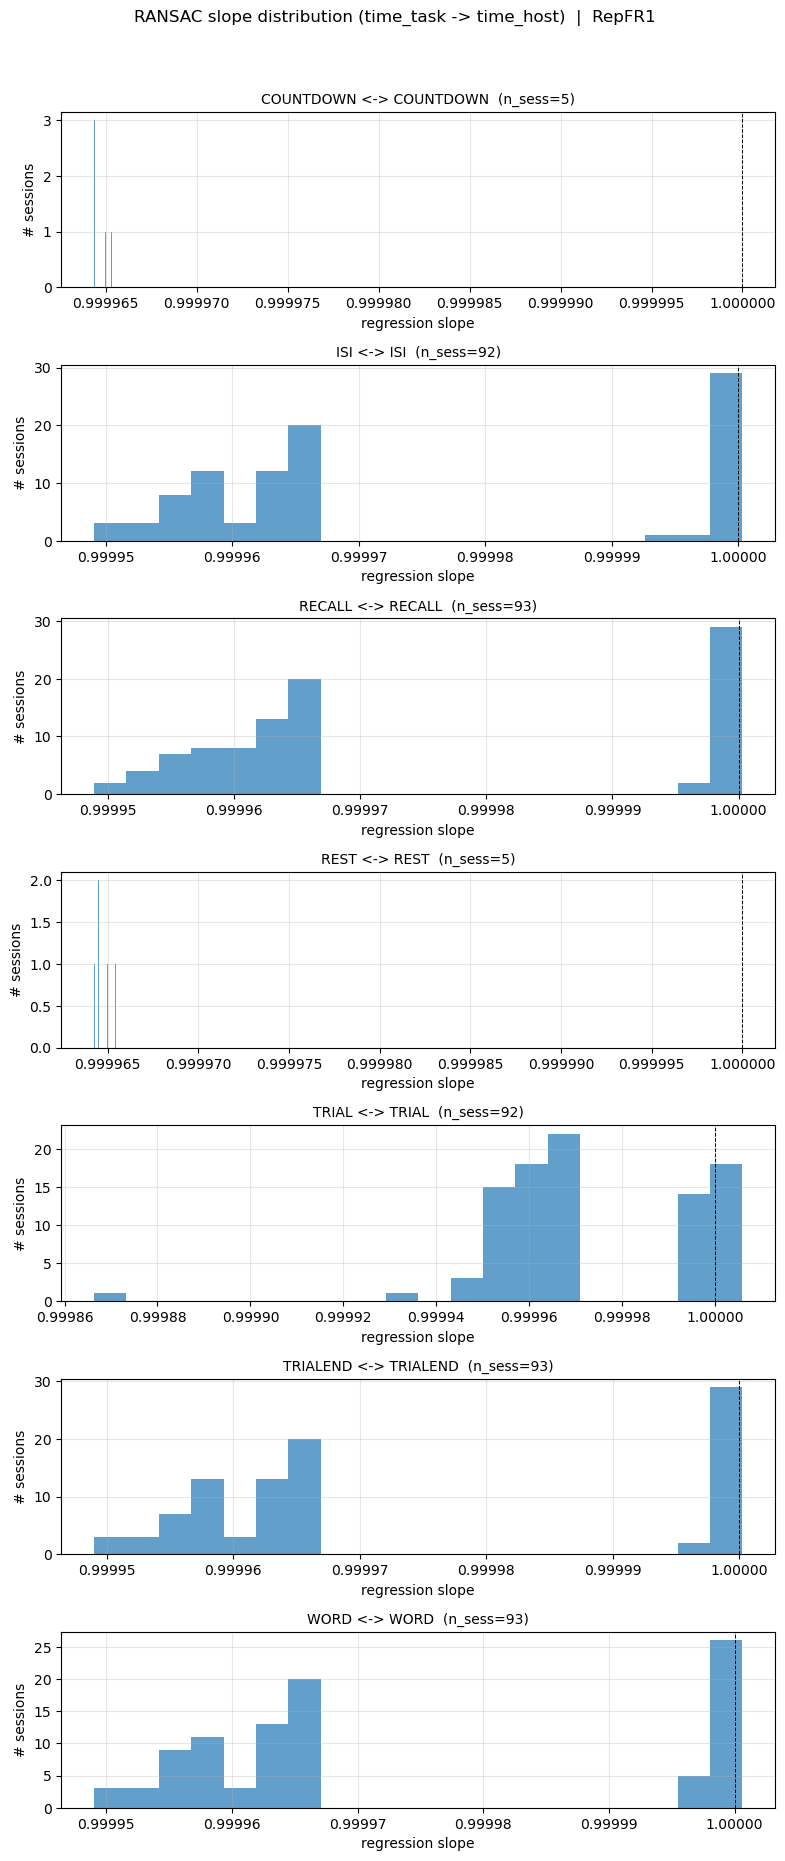

In [12]:
# Slope distribution per top candidate (one figure per experiment).
cnh.plot_slope_distribution(corrections_eval, top_candidates)


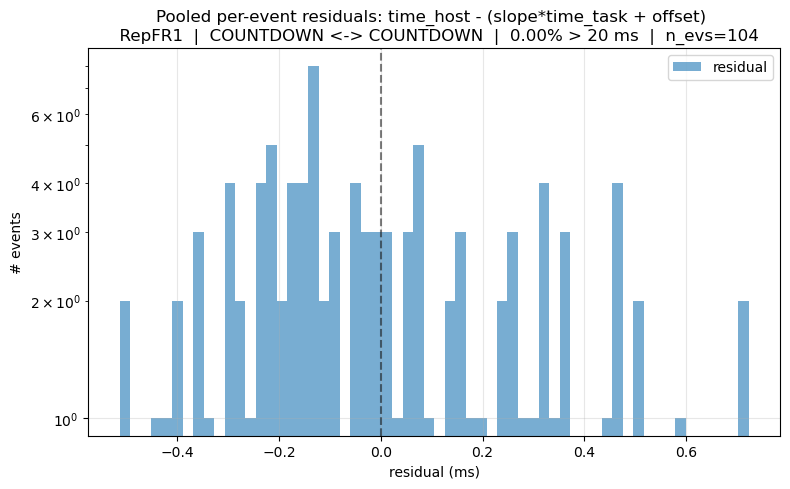

  residual median=-0.054 ms, std=0.276 ms, p95(|x|)=0.503 ms, max(|x|)=0.723 ms



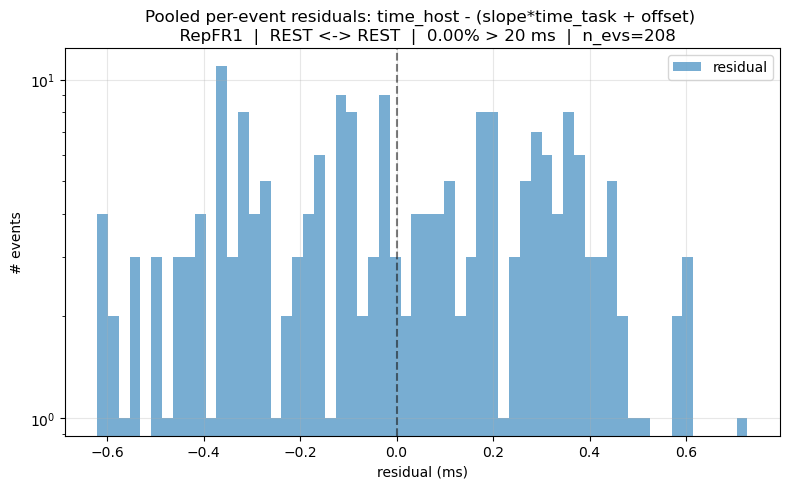

  residual median=-0.008 ms, std=0.315 ms, p95(|x|)=0.576 ms, max(|x|)=0.728 ms



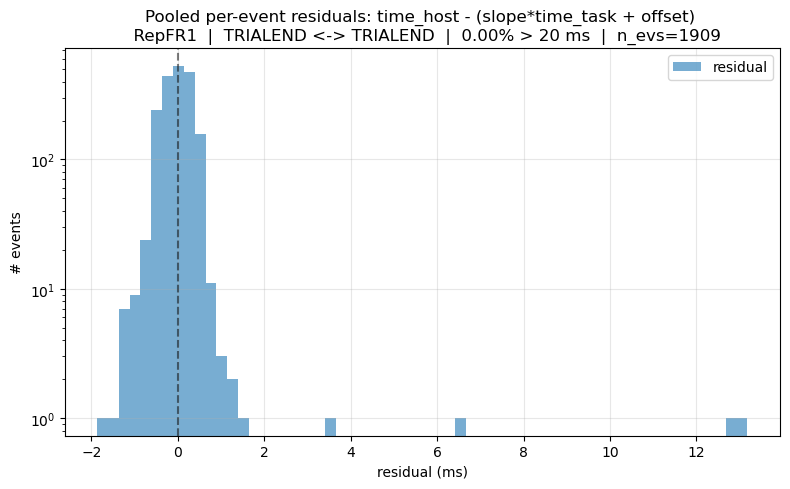

  residual median=-0.005 ms, std=0.558 ms, p95(|x|)=0.579 ms, max(|x|)=13.182 ms



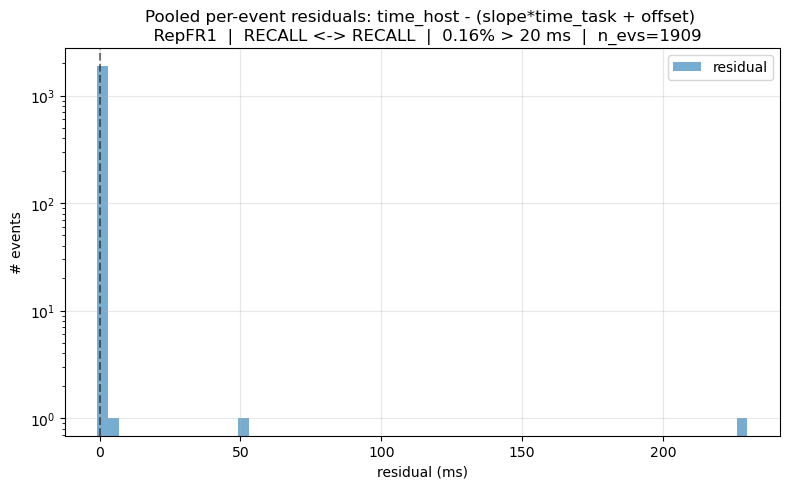

  residual median=-0.010 ms, std=36.522 ms, p95(|x|)=0.565 ms, max(|x|)=1578.324 ms



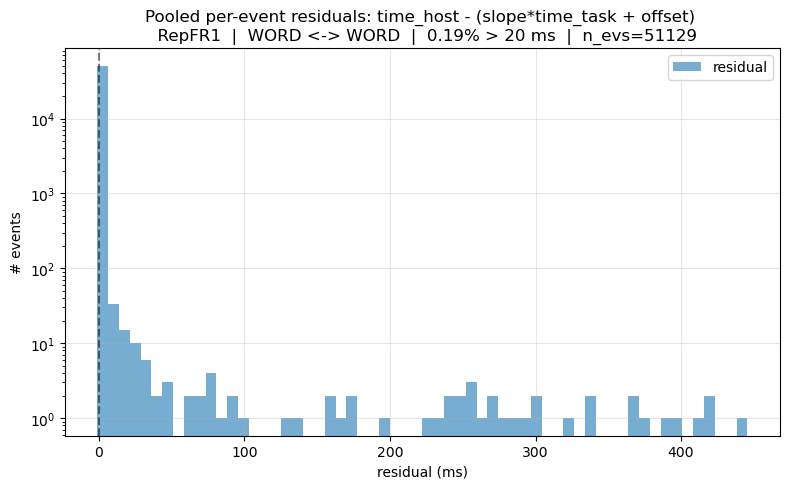

  residual median=-0.016 ms, std=37.130 ms, p95(|x|)=0.588 ms, max(|x|)=1579.222 ms



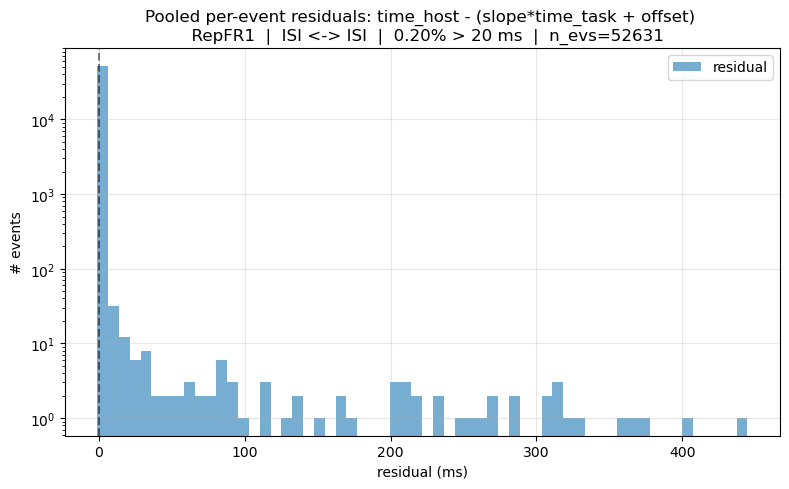

  residual median=-0.018 ms, std=37.105 ms, p95(|x|)=0.609 ms, max(|x|)=1578.846 ms



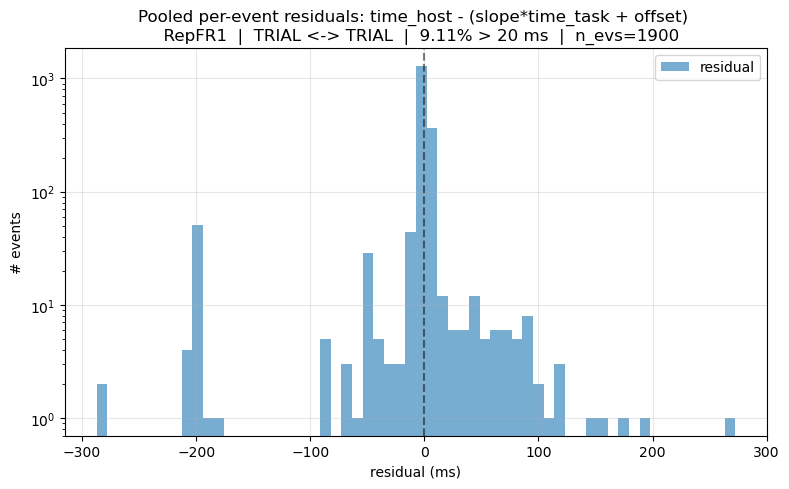

  residual median=-0.356 ms, std=53.241 ms, p95(|x|)=69.397 ms, max(|x|)=1532.990 ms



In [13]:
# Per-top-candidate residual histograms pooled across sessions.
cnh.plot_pooled_residual_hist(
    corrections_eval, top_candidates, session_event_cache)


# Compared to GT — correcting all events

Take the per-session non-heart fits and apply slope/offset to every paired event, then compare the corrected timeline to the heartbeat ground-truth fit. Quantifies how well a fully-applied correction reproduces GT.

In [14]:
# Fit heartbeat-based (ground-truth) correction per session with plain
# OLS on the merged_df produced upstream. The merged_df has already been
# filtered to HBs whose one-way latency is at the ~1 ms network floor,
# so no RANSAC outlier rejection is needed here. Offset is adjusted by
# the median one-way latency, matching the network-delay correction the
# old fit_correction() applied.
from sklearn.linear_model import LinearRegression

gt_rows = []
for (sub, exp, sess, orig_sess), prep in prepared_by_sess.items():
    merged_df = prep['merged_df']
    if merged_df is None or len(merged_df) < MIN_GT_HEARTBEATS:
        continue

    lr = LinearRegression()
    lr.fit(merged_df[['time_task']].astype(float),
           merged_df['time_host'].astype(float))
    slope          = float(lr.coef_[0])
    offset_raw     = float(lr.intercept_)
    median_one_way = float(merged_df['one_way_latency_ms'].median())
    offset         = offset_raw - median_one_way

    residuals    = (merged_df['time_host'].astype(float)
                    - (slope * merged_df['time_task'].astype(float) + offset_raw))
    rms_residual = float(np.sqrt((residuals ** 2).mean()))

    gt_rows.append({
        'subject':            sub,
        'experiment':         exp,
        'session':            sess,
        'original_session':   orig_sess,
        'slope':              slope,
        'offset':             offset,
        'uncorrected_offset': offset_raw,
        'average_latency':    2.0 * median_one_way,
        'n_inliers':          int(len(merged_df)),
        'rms_residual':       rms_residual,
    })
gt_corrections = pd.DataFrame(gt_rows)
print(f'GT (heartbeat) corrections: {len(gt_corrections)} sessions  '
      f'(OLS on one-way-latency-filtered HBs)')
display(gt_corrections)


GT (heartbeat) corrections: 95 sessions  (OLS on one-way-latency-filtered HBs)


,subject,experiment,session,original_session,slope,offset,uncorrected_offset,average_latency,n_inliers,rms_residual
0,R1204T,RepFR1,0,0,0.999962,6.151258e+07,6.151258e+07,0.869873,4137,0.341868
1,R1204T,RepFR1,1,1,0.999962,6.181449e+07,6.181449e+07,0.900146,2984,0.293137
2,R1204T,RepFR1,2,2,0.999962,6.199534e+07,6.199534e+07,1.060059,2757,0.369254
3,R1556J,RepFR1,1,1,0.999964,6.858142e+07,6.858142e+07,1.149902,3475,0.418668
4,R1579T,RepFR1,0,0,0.999959,6.646785e+07,6.646785e+07,1.260010,2145,0.336669
...,...,...,...,...,...,...,...,...,...,...
90,R1681J,RepFR1,3,3,0.999998,1.440346e+07,1.440346e+07,1.510010,1481,0.391204
91,R1681J,RepFR1,4,4,0.999998,1.435603e+07,1.435603e+07,1.489990,1492,0.317630
92,R1690E,RepFR1,0,0,0.999998,4.021714e+06,4.021714e+06,1.510010,265,0.419188
93,R1690E,RepFR1,1,1,0.999997,4.235205e+06,4.235206e+06,1.530029,354,0.556165


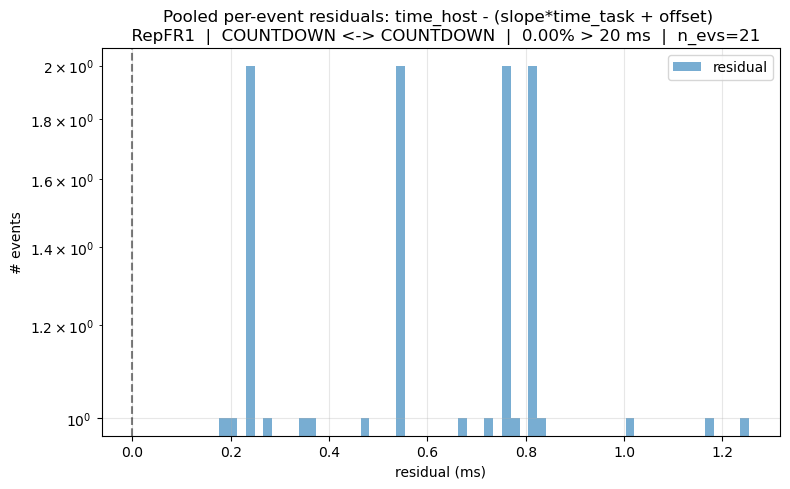

  residual median=0.667 ms, std=0.319 ms, p95(|x|)=1.182 ms, max(|x|)=1.254 ms



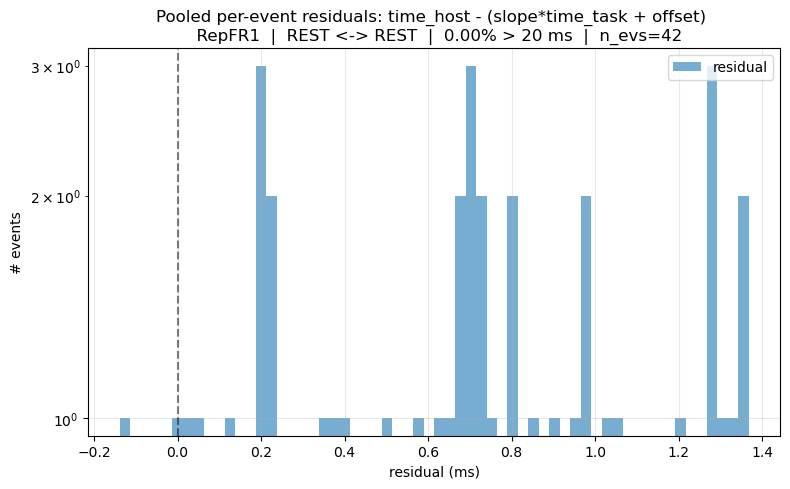

  residual median=0.704 ms, std=0.424 ms, p95(|x|)=1.321 ms, max(|x|)=1.367 ms



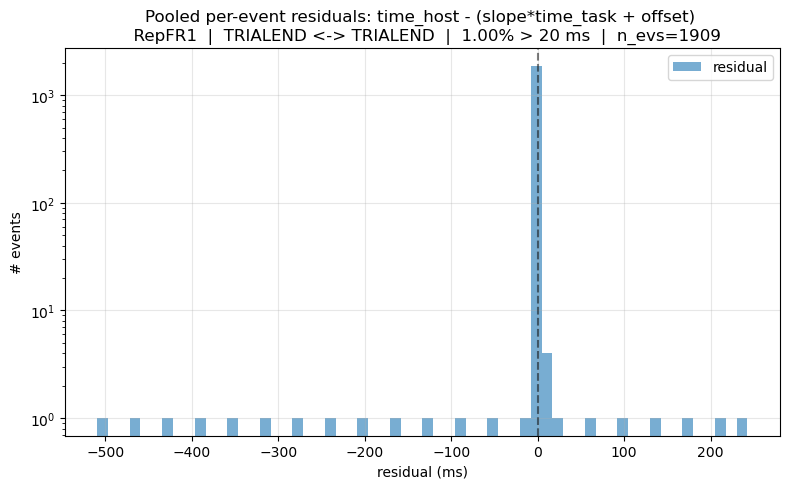

  residual median=0.723 ms, std=27.235 ms, p95(|x|)=1.299 ms, max(|x|)=509.549 ms



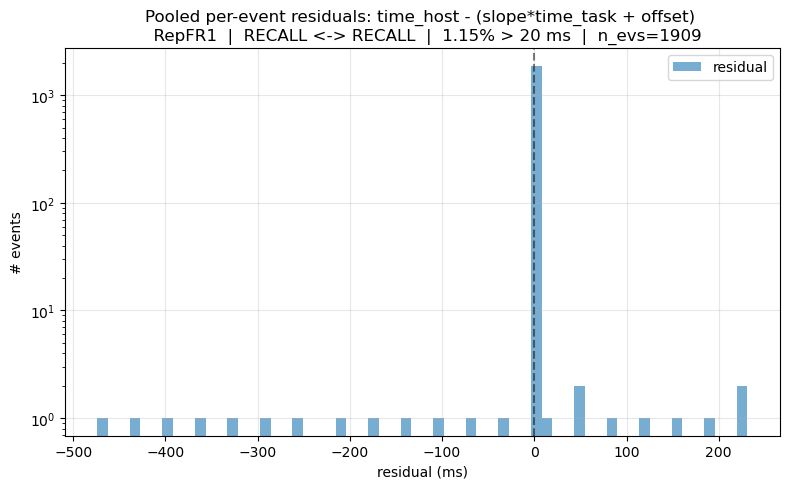

  residual median=0.781 ms, std=35.335 ms, p95(|x|)=1.477 ms, max(|x|)=1057.214 ms



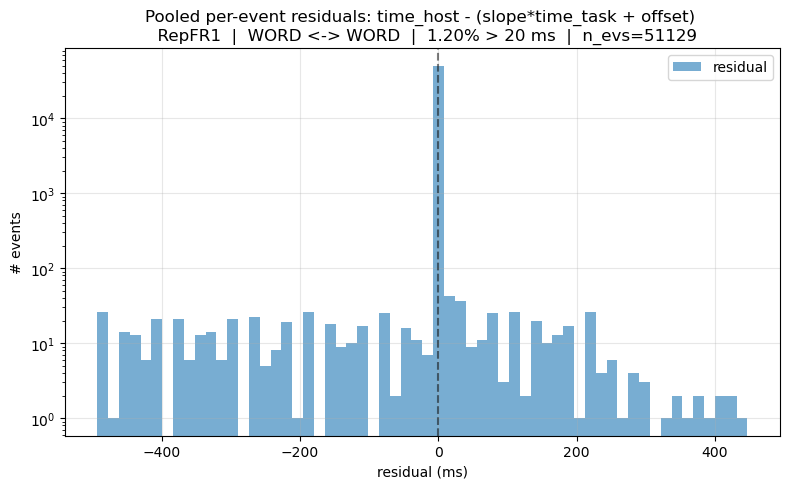

  residual median=0.802 ms, std=36.208 ms, p95(|x|)=1.546 ms, max(|x|)=1053.625 ms



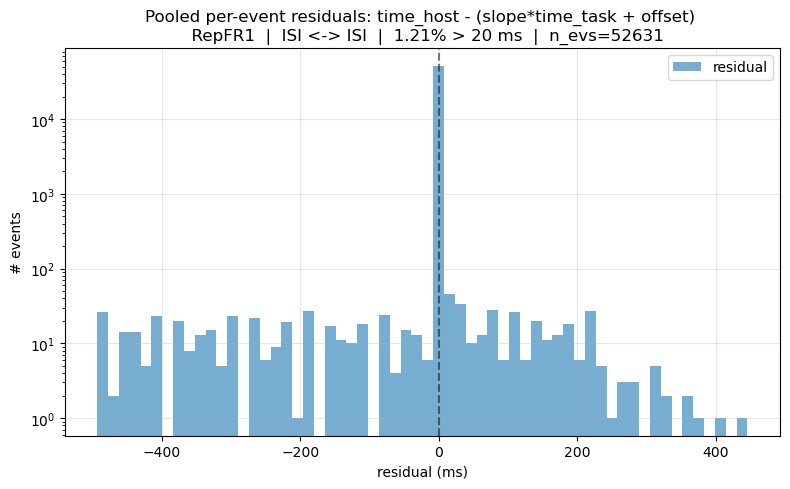

  residual median=0.801 ms, std=36.177 ms, p95(|x|)=1.632 ms, max(|x|)=1053.915 ms



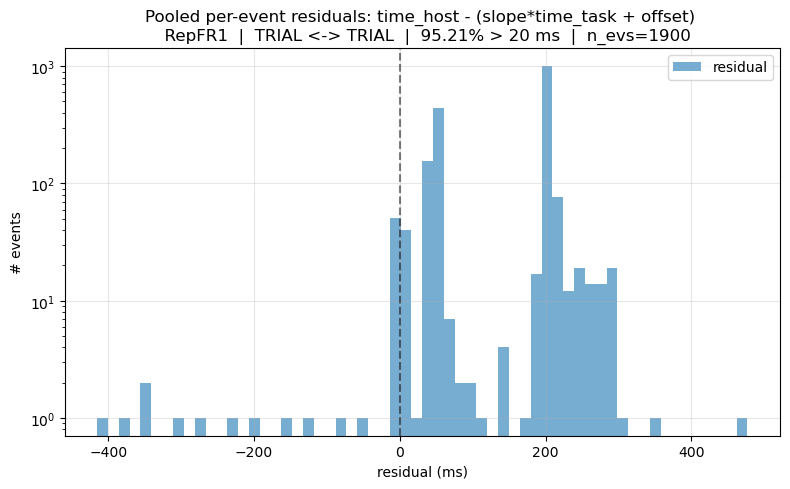

  residual median=200.017 ms, std=88.778 ms, p95(|x|)=221.132 ms, max(|x|)=1032.576 ms



In [15]:
# Pooled per-event residual histograms taken against the per-session HEARTBEAT
gt_lookup = {
    (r.subject, r.experiment, int(r.session)): (float(r.slope), float(r.offset))
    for r in gt_corrections.itertuples()
}

corrections_eval_gt = corrections_eval.copy()
sess_keys = list(zip(corrections_eval_gt['subject'],
                     corrections_eval_gt['experiment'],
                     corrections_eval_gt['session'].astype(int)))
corrections_eval_gt['slope']  = [gt_lookup.get(k, (float('nan'), float('nan')))[0]
                                 for k in sess_keys]
corrections_eval_gt['offset'] = [gt_lookup.get(k, (float('nan'), float('nan')))[1]
                                 for k in sess_keys]
corrections_eval_gt = corrections_eval_gt.dropna(subset=['slope', 'offset'])

cnh.plot_pooled_residual_hist(corrections_eval_gt, top_candidates,
                              session_event_cache)


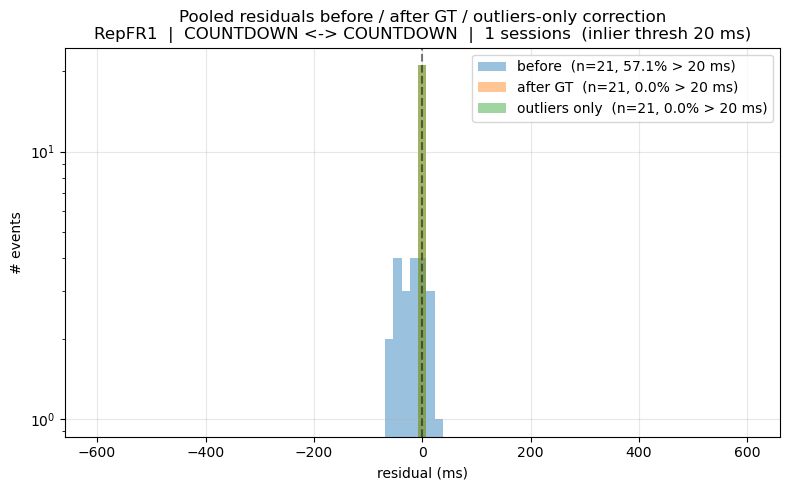

  before  : median=-18.215 ms, std=26.340 ms, p95(|x|)=55.777 ms
  after   : median=0.667 ms, std=0.319 ms, p95(|x|)=1.182 ms
  outliers: median=0.667 ms, std=0.319 ms, p95(|x|)=1.182 ms



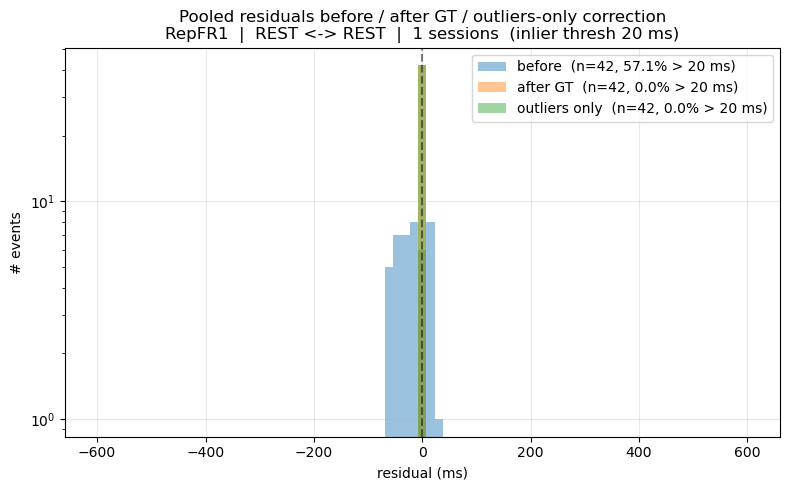

  before  : median=-18.993 ms, std=25.937 ms, p95(|x|)=58.125 ms
  after   : median=0.704 ms, std=0.424 ms, p95(|x|)=1.321 ms
  outliers: median=0.704 ms, std=0.424 ms, p95(|x|)=1.321 ms



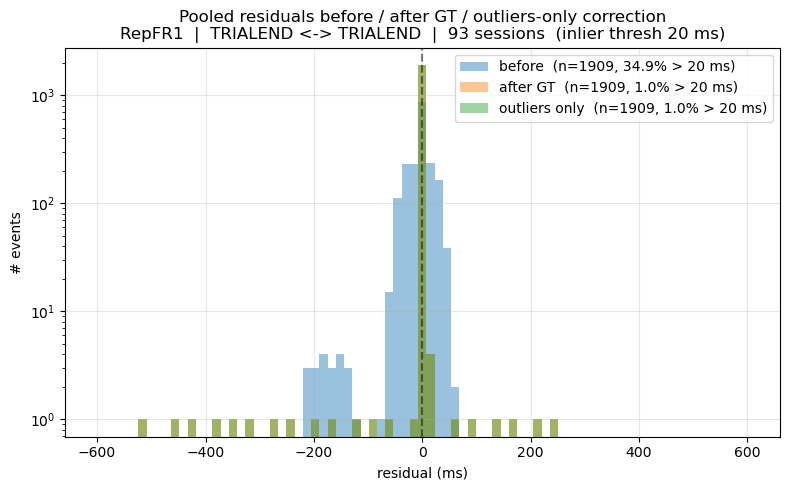

  before  : median=-0.096 ms, std=27.050 ms, p95(|x|)=44.521 ms
  after   : median=0.723 ms, std=27.235 ms, p95(|x|)=1.299 ms
  outliers: median=0.723 ms, std=27.235 ms, p95(|x|)=1.299 ms



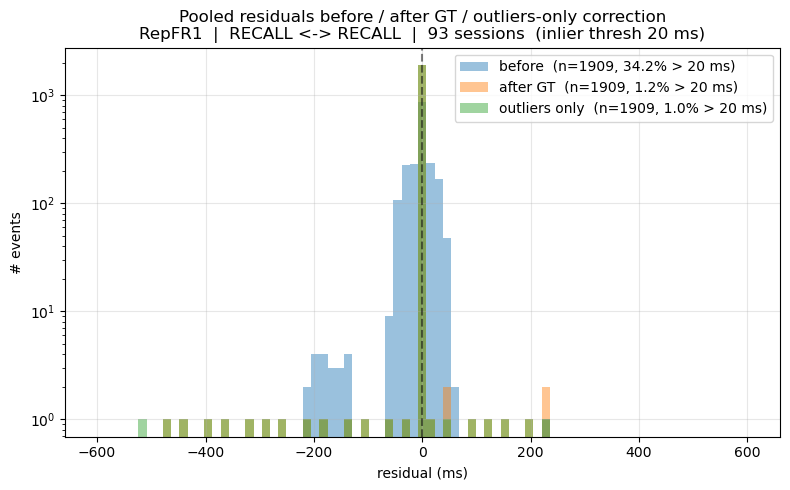

  before  : median=0.112 ms, std=43.144 ms, p95(|x|)=44.174 ms
  after   : median=0.781 ms, std=35.335 ms, p95(|x|)=1.477 ms
  outliers: median=0.781 ms, std=27.842 ms, p95(|x|)=1.475 ms



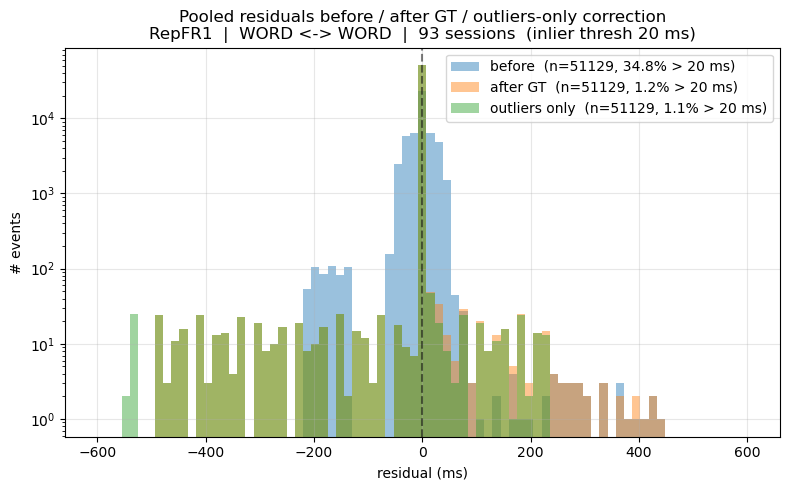

  before  : median=0.234 ms, std=43.693 ms, p95(|x|)=43.840 ms
  after   : median=0.802 ms, std=36.208 ms, p95(|x|)=1.546 ms
  outliers: median=0.801 ms, std=28.594 ms, p95(|x|)=1.542 ms



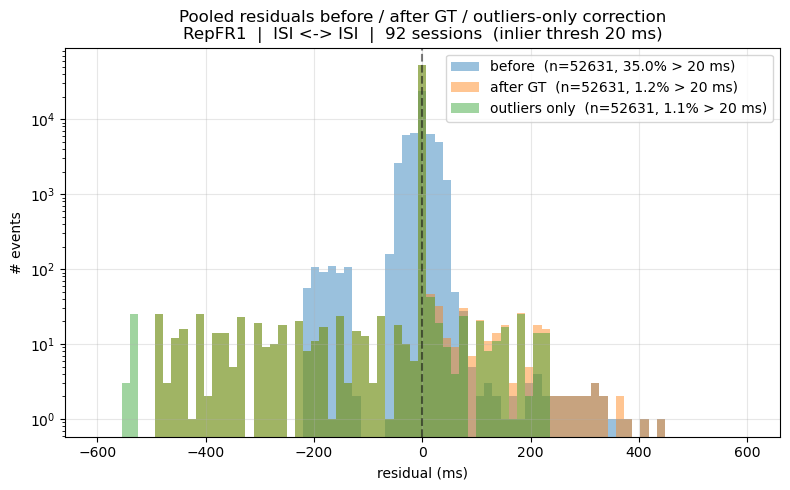

  before  : median=0.297 ms, std=43.702 ms, p95(|x|)=43.956 ms
  after   : median=0.801 ms, std=36.177 ms, p95(|x|)=1.632 ms
  outliers: median=0.801 ms, std=28.704 ms, p95(|x|)=1.624 ms



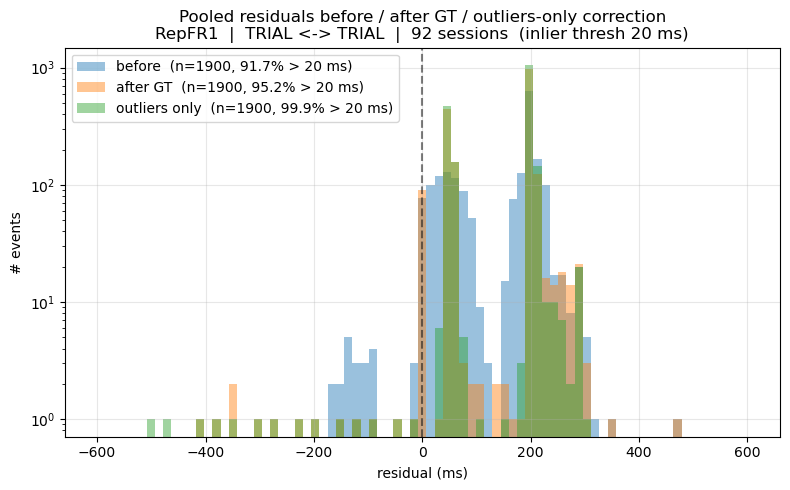

  before  : median=191.668 ms, std=89.925 ms, p95(|x|)=230.014 ms
  after   : median=200.017 ms, std=88.778 ms, p95(|x|)=221.132 ms
  outliers: median=200.096 ms, std=82.330 ms, p95(|x|)=210.325 ms



In [16]:
# Pooled residuals BEFORE vs AFTER applying the heartbeat-GT correction,
# plus a third series: GT residuals after an OUTLIERS-ONLY correction.
#
# Per session, all three residuals are computed against the heartbeat fit:
#   before        : h - (1 * t + offset_hb)
#       offset_hb = mean(time_host - time_task) over that session's merged
#       heartbeats = the heartbeat-derived constant clock offset under the
#       slope=1 (no-drift) hypothesis. Synced clocks but no slope correction.
#   after GT      : h - (slope_gt * t + offset_gt)
#       full heartbeat-derived linear correction.
#   outliers only : corrected_h - (slope_gt * t + offset_gt), where
#       inliers (|h - (slope_nh*t + offset_nh)| <= INLIER_MS) keep raw h
#       and outliers get snapped to (slope_nh*t + offset_nh).
import numpy as np
import matplotlib.pyplot as plt

ABS_THRESHOLD_MS = 20
CLIP_MS          = 600
INLIER_MS        = cnh.RANSAC_INLIER_MS

gt_lookup = {
    (r.subject, r.experiment, int(r.session)): (float(r.slope), float(r.offset))
    for r in gt_corrections.itertuples()
}

# Heartbeat-derived slope-1 offset per session: mean(time_host - time_task)
# across that session's filtered merged heartbeats.
hb_offset_lookup = {}
for (sub, exp, sess, _orig), prep in prepared_by_sess.items():
    md = prep.get('merged_df')
    if md is None or len(md) == 0:
        continue
    hb_offset_lookup[(sub, exp, int(sess))] = float(
        (md['time_host'].astype(float) - md['time_task'].astype(float)).mean())

for _, c in (top_candidates[['experiment', 'task_type', 'host_type']]
             .drop_duplicates().iterrows()):
    sel = corrections_eval.dropna(subset=['slope']).query(
        "experiment == @c.experiment and task_type == @c.task_type "
        "and host_type == @c.host_type")
    before, after, outliers = [], [], []
    n_sess = 0
    for _, sess_row in sel.iterrows():
        key = (sess_row['subject'], sess_row['experiment'],
               int(sess_row['session']))
        if key not in gt_lookup or key not in hb_offset_lookup:
            continue
        slope_gt, offset_gt = gt_lookup[key]
        offset_hb           = hb_offset_lookup[key]
        slope_nh, offset_nh = float(sess_row['slope']), float(sess_row['offset'])
        cache = session_event_cache.get(key)
        if cache is None:
            continue
        t_times = cache['task_by_type'].get(c['task_type'], [])
        h_times = cache['host_by_type'].get(c['host_type'], [])
        n = min(len(t_times), len(h_times))
        if n < 3:
            continue
        t = np.asarray(t_times[:n], dtype=float)
        h = np.asarray(h_times[:n], dtype=float)

        nh_pred     = slope_nh * t + offset_nh
        inlier_mask = np.abs(h - nh_pred) <= INLIER_MS
        corrected_h = np.where(inlier_mask, h, nh_pred)

        before  .extend((h - (t + offset_hb)).tolist())
        after   .extend((h - (slope_gt * t + offset_gt)).tolist())
        outliers.extend((corrected_h - (slope_gt * t + offset_gt)).tolist())
        n_sess += 1

    before   = np.array(before)
    after    = np.array(after)
    outliers = np.array(outliers)
    if before.size == 0:
        continue

    def _pct(a):
        return 100 * (np.abs(a) > ABS_THRESHOLD_MS).sum() / a.size

    plt.figure(figsize=(8, 5))
    bins = np.linspace(-CLIP_MS, CLIP_MS, 80)
    plt.hist(before  [np.abs(before)   < CLIP_MS], bins=bins, alpha=0.45,
             label=f'before  (n={before.size}, {_pct(before):.1f}% > {ABS_THRESHOLD_MS} ms)')
    plt.hist(after   [np.abs(after)    < CLIP_MS], bins=bins, alpha=0.45,
             label=f'after GT  (n={after.size}, {_pct(after):.1f}% > {ABS_THRESHOLD_MS} ms)')
    plt.hist(outliers[np.abs(outliers) < CLIP_MS], bins=bins, alpha=0.45,
             label=f'outliers only  (n={outliers.size}, {_pct(outliers):.1f}% > {ABS_THRESHOLD_MS} ms)')
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.yscale('log')
    plt.xlabel('residual (ms)')
    plt.ylabel('# events')
    plt.legend()
    plt.title(
        f'Pooled residuals before / after GT / outliers-only correction\n'
        f'{c["experiment"]}  |  {c["task_type"]} <-> {c["host_type"]}  |  '
        f'{n_sess} sessions  (inlier thresh {INLIER_MS:g} ms)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    for name, a in (('before  ', before), ('after   ', after),
                    ('outliers', outliers)):
        print(f'  {name}: median={np.median(a):.3f} ms, '
              f'std={a.std(ddof=1):.3f} ms, '
              f'p95(|x|)={np.percentile(np.abs(a), 95):.3f} ms')
    print()


In [17]:
# Diagnostic: where does each plot's `n` come from for COUNTDOWN?
# Counts the populations feeding (slope hist, NH residual hist, GT residual hist).
exp, t_name, h_name = 'RepFR1', 'COUNTDOWN', 'COUNTDOWN'

# (1) Slope hist: sessions with non-NaN RANSAC slope.
sel_nh = corrections_eval.dropna(subset=['slope']).query(
    "experiment == @exp and task_type == @t_name and host_type == @h_name")
print(f'slope-hist n (sessions w/ non-NaN RANSAC slope): {len(sel_nh)}')

# (2) NH residual hist: pooled events from those sessions, each contributing min(nT, nH).
def pool_for(sel):
    n_events = n_sess = 0
    for _, r in sel.iterrows():
        cache = session_event_cache.get(
            (r['subject'], r['experiment'], int(r['session'])))
        if cache is None:
            continue
        nT = len(cache['task_by_type'].get(t_name, []))
        nH = len(cache['host_by_type'].get(h_name, []))
        if min(nT, nH) >= 3:
            n_events += min(nT, nH)
            n_sess   += 1
    return n_events, n_sess

p_nh, s_nh = pool_for(sel_nh)
print(f'NH residual-hist n (pooled events): {p_nh}  ({s_nh} sessions)')

# (3) GT residual hist: same population, but slope/offset are overwritten with GT,
#     then dropna() runs again. Sessions where NH slope was NaN are now rescued
#     (their GT slope is valid), so the GT pool can include MORE rows than NH.
gt_keys = {(r.subject, r.experiment, int(r.session))
           for r in gt_corrections.itertuples()}
ce_gt = corrections_eval.copy()
ce_gt['_has_gt'] = ce_gt.apply(
    lambda r: (r['subject'], r['experiment'], int(r['session'])) in gt_keys, axis=1)
sel_gt = ce_gt.query(
    "experiment == @exp and task_type == @t_name and host_type == @h_name and _has_gt")
p_gt, s_gt = pool_for(sel_gt)
print(f'GT residual-hist n (pooled events): {p_gt}  ({s_gt} sessions)')

# Reconcile: rows where NH dropped them but GT keeps them.
rescued = corrections_eval[corrections_eval['slope'].isna()].query(
    "experiment == @exp and task_type == @t_name and host_type == @h_name")
print(f'rows rescued by GT (NaN NH slope, present in gt_corrections): '
      f'{sum(1 for _, r in rescued.iterrows() if (r["subject"], r["experiment"], int(r["session"])) in gt_keys)}')


slope-hist n (sessions w/ non-NaN RANSAC slope): 5
NH residual-hist n (pooled events): 104  (5 sessions)
GT residual-hist n (pooled events): 21  (1 sessions)
rows rescued by GT (NaN NH slope, present in gt_corrections): 0


In [18]:
# Per-top-candidate vs GT: compute on every session, then pick rep.
# mode='all_events' compares raw h to GT (matches original behavior).
per_cand_all = cnh.compute_per_candidate_vs_gt(
    top_candidates, session_event_cache, gt_corrections,
    corrections_eval=corrections_eval, mode='all_events',
)
per_cand_rep = cnh.pick_rep_per_experiment(per_cand_all, corrections_eval)


In [19]:
cnh.plot_per_candidate_vs_gt(per_cand_rep)


TypeError: plot_per_candidate_vs_gt() missing 2 required positional arguments: 'residual_summary' and 'top_candidates'

# Drift — non-heart self-evaluation

Scalar-per-(candidate, session) drift implied by the non-heart fit over a typical 3600 s session: `(slope_nh - 1) * SESS_SECONDS * SFREQ_REF`. **BEFORE** = drift the non-heart fit thinks it removes. **AFTER** = 0 by construction (sanity check that applying `slope_nh` cancels exactly its own implied drift). Drift is a property of the fitted slope, so it does not depend on correction mode.

In [ ]:
# drift_df_nh = cnh.compute_drift_per_candidate(corrections_eval, top_candidates)
# display(drift_df_nh.describe())
# cnh.plot_eegoffset_drift_distribution(drift_df_nh, top_candidates)
# cnh.plot_wallclock_drift_distribution(drift_df_nh, top_candidates)


# Drift — non-heart fit evaluated against heartbeat GT

**BEFORE** = actual drift in the raw signal, estimated by the heartbeat GT slope: `(slope_gt - 1) * SESS_SECONDS * SFREQ_REF`. **AFTER** = drift remaining after applying the non-heart correction, vs GT: `(slope_gt - slope_nh) * SESS_SECONDS * SFREQ_REF`. AFTER tells us how much drift the non-heart fit fails to remove relative to the heartbeat ground truth.

In [ ]:
drift_df_gt = cnh.compute_drift_per_candidate_gt(
    corrections_eval, gt_corrections, top_candidates,
)
# Attach the real per-session EEG samplerate and recompute drift in
# samples. The shared helper now only emits drift_*_ms (sfreq-free); the
# notebook owns the sample-rate-dependent conversion.
drift_df_gt['samplerate'] = drift_df_gt.apply(
    lambda r: samplerates_by_sess.get(
        (r['subject'], r['experiment'], int(r['session'])), float('nan')),
    axis=1,
)
drift_df_gt['drift_before_samples'] = (
    drift_df_gt['drift_before_ms'] * drift_df_gt['samplerate'] / 1000.0
)
drift_df_gt['drift_after_samples'] = (
    drift_df_gt['drift_after_ms'] * drift_df_gt['samplerate'] / 1000.0
)
display(drift_df_gt.describe())

,session,slope_nh,slope_gt,n_pairs,n_inliers,n_outliers,inlier_frac,drift_before_ms,drift_after_ms,samplerate,drift_before_samples,drift_after_samples
count,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,460.000000,460.000000,460.000000
mean,1.212903,0.999973,0.999970,235.572043,234.756989,0.815054,0.980561,-109.732079,-13.843822,1010.869565,-110.355848,-14.246857
std,1.383339,0.000019,0.000044,269.476327,269.232016,2.710967,0.064231,159.686109,141.102050,103.801933,161.062385,142.119186
min,0.000000,0.999866,0.999583,4.000000,3.000000,0.000000,0.380952,-1500.827622,-1350.520404,1000.000000,-1500.827622,-1350.520404
25%,0.000000,0.999959,0.999959,21.000000,21.000000,0.000000,1.000000,-147.132266,-0.437393,1000.000000,-147.164562,-0.451959
50%,1.000000,0.999965,0.999965,21.000000,21.000000,0.000000,1.000000,-125.373035,-0.124842,1000.000000,-124.096497,-0.127276
75%,2.000000,0.999998,0.999998,567.000000,567.000000,0.000000,1.000000,-6.025412,0.102450,1000.000000,-6.025412,0.103084
max,6.000000,1.000006,1.000000,588.000000,588.000000,28.000000,1.000000,0.964995,472.274616,2000.000000,0.964995,472.274616


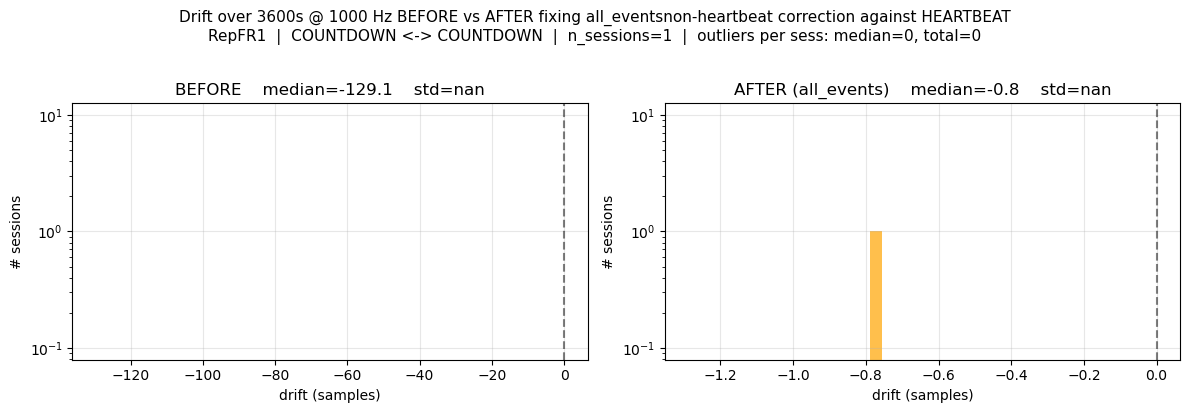

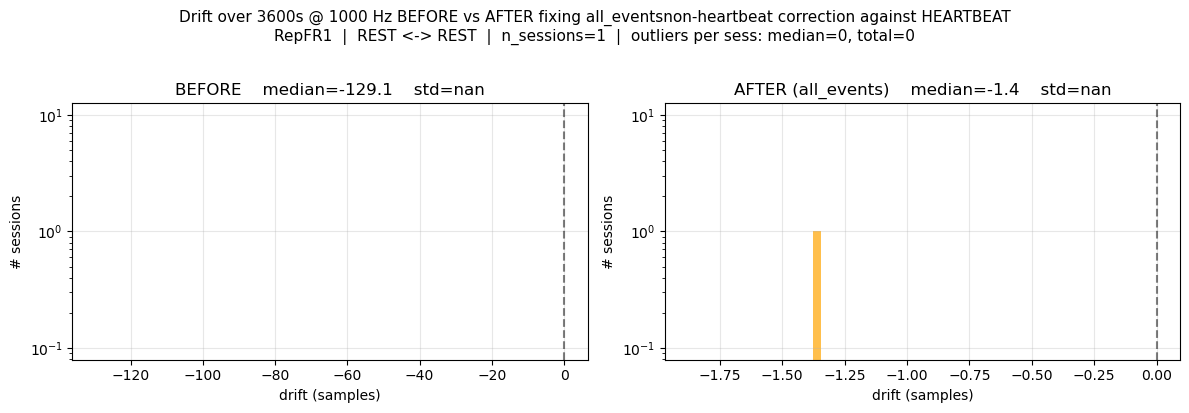

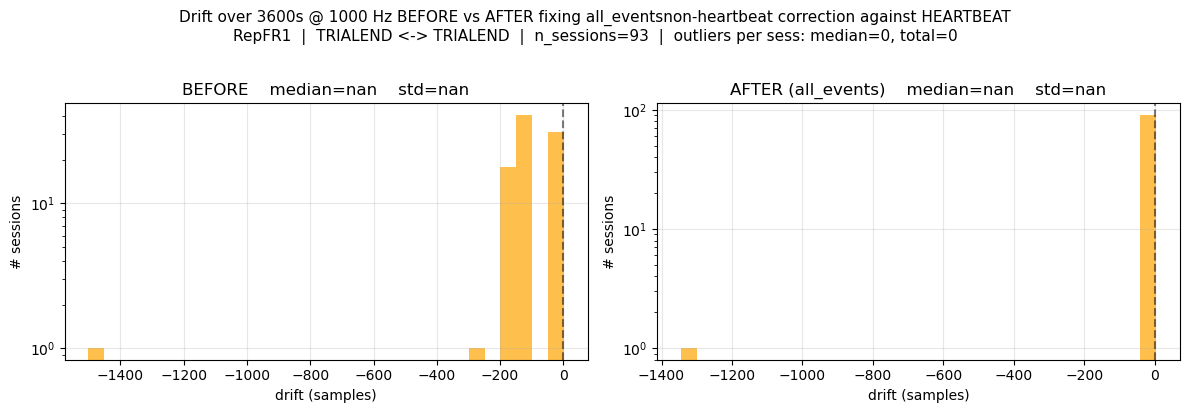

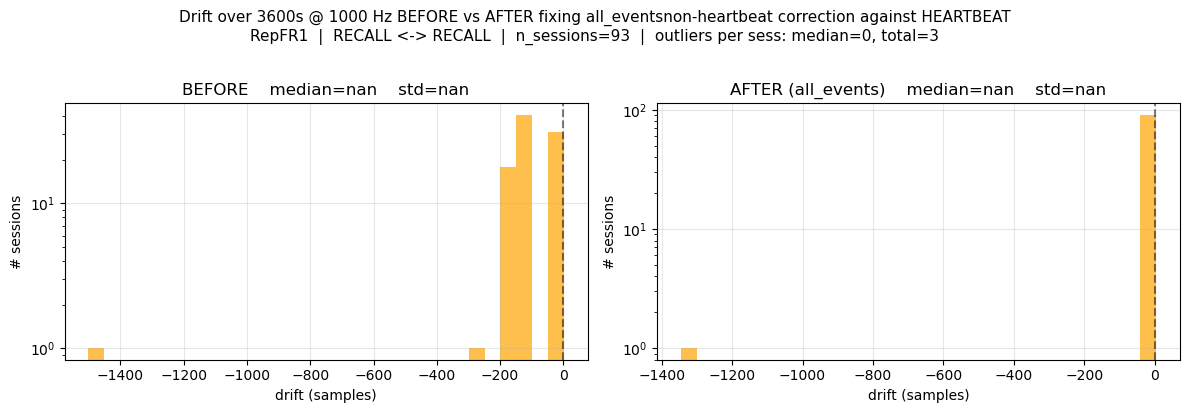

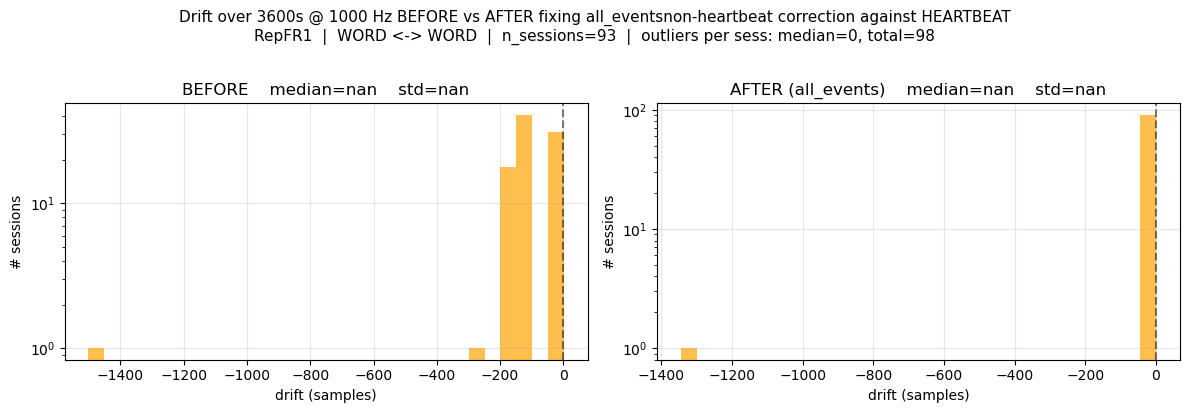

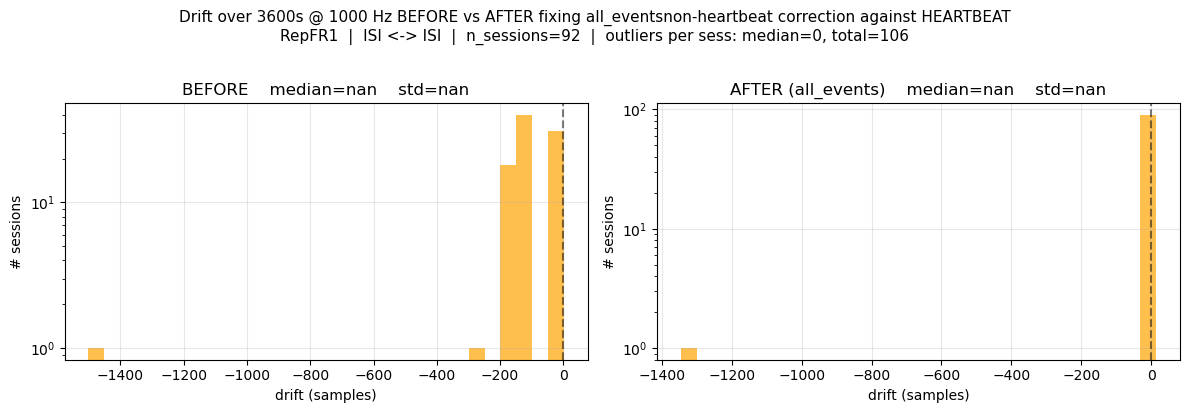

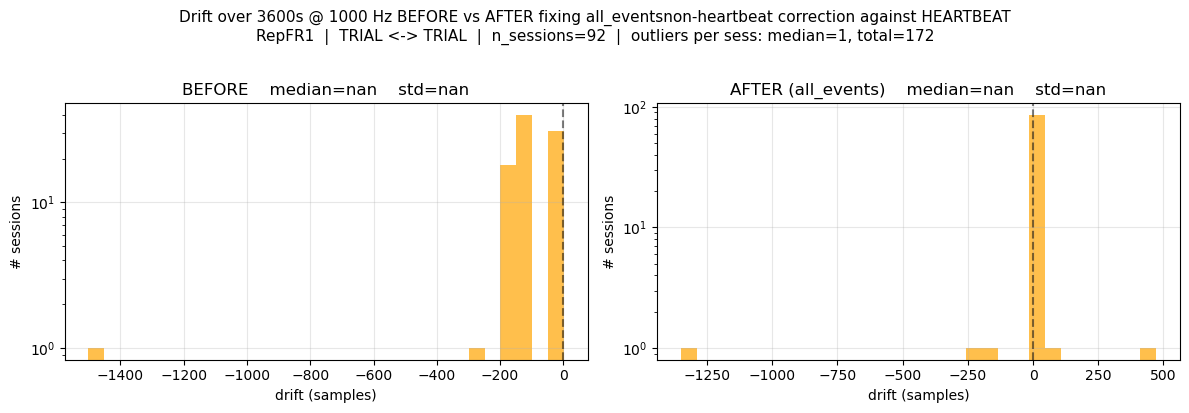

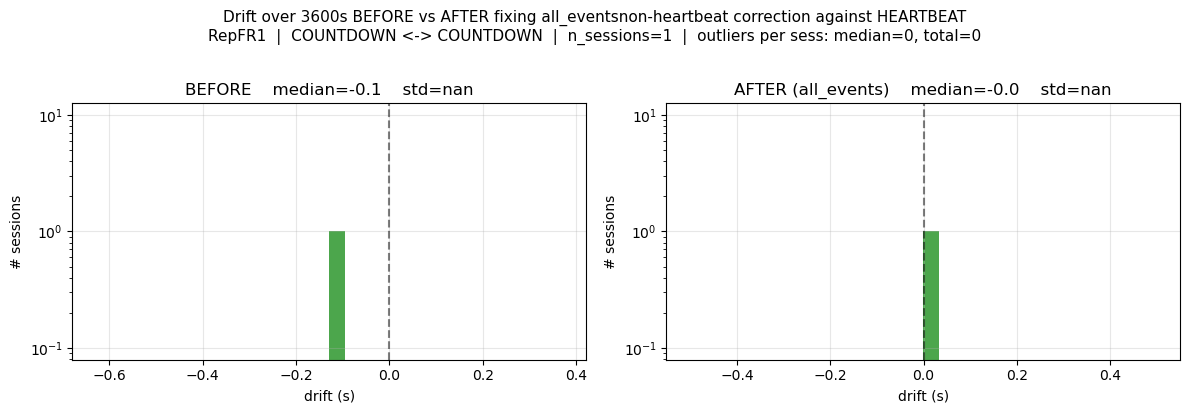

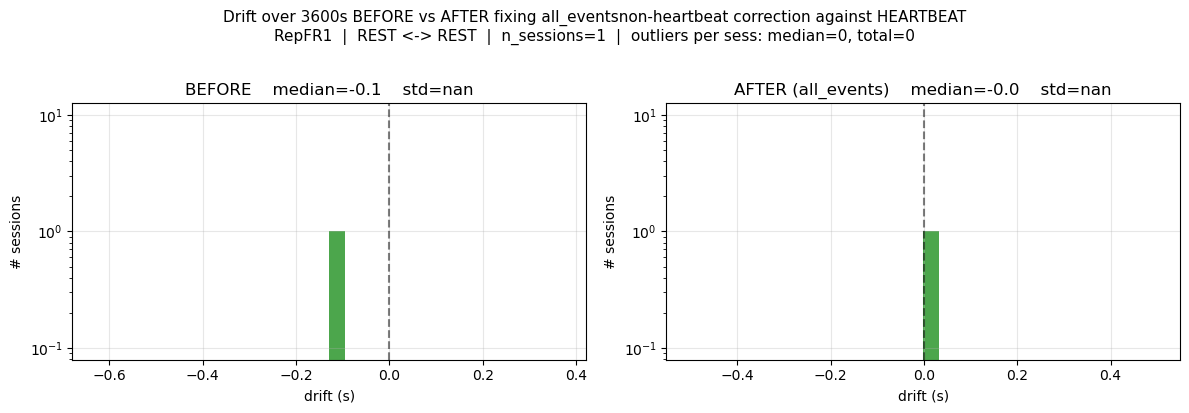

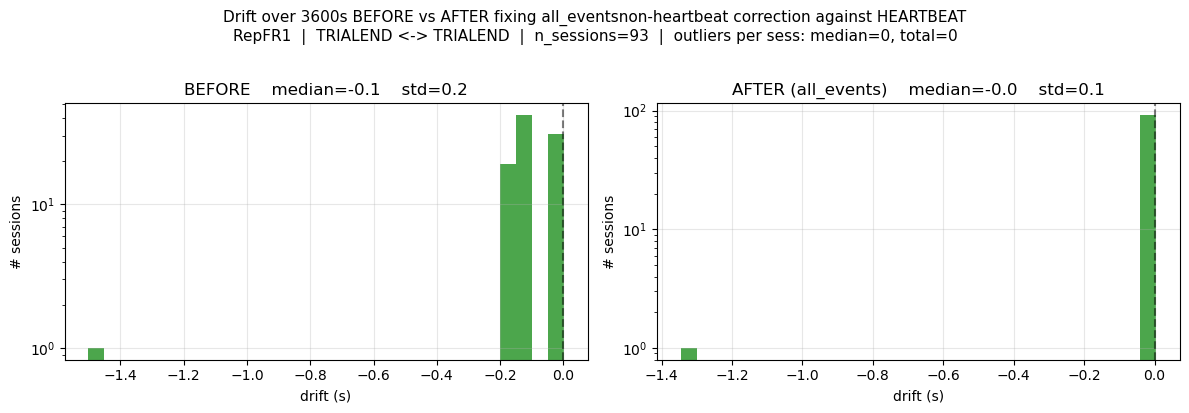

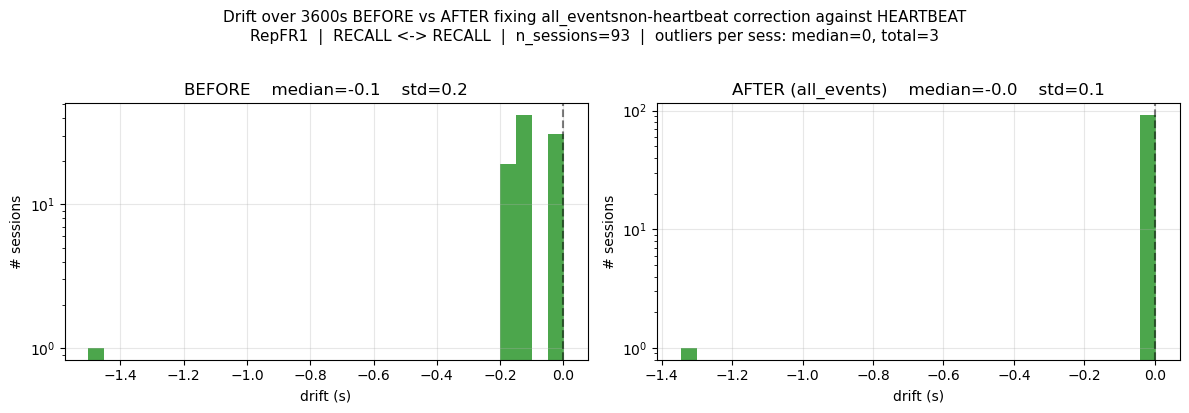

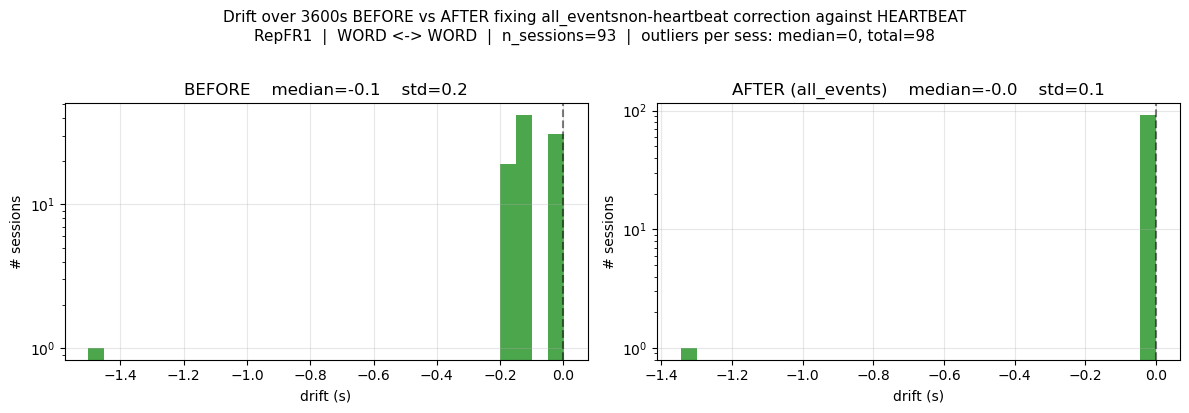

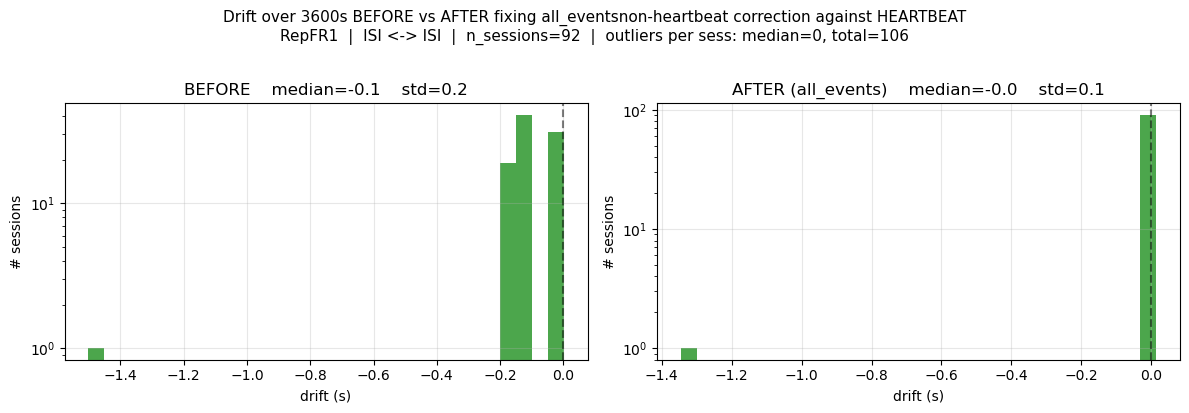

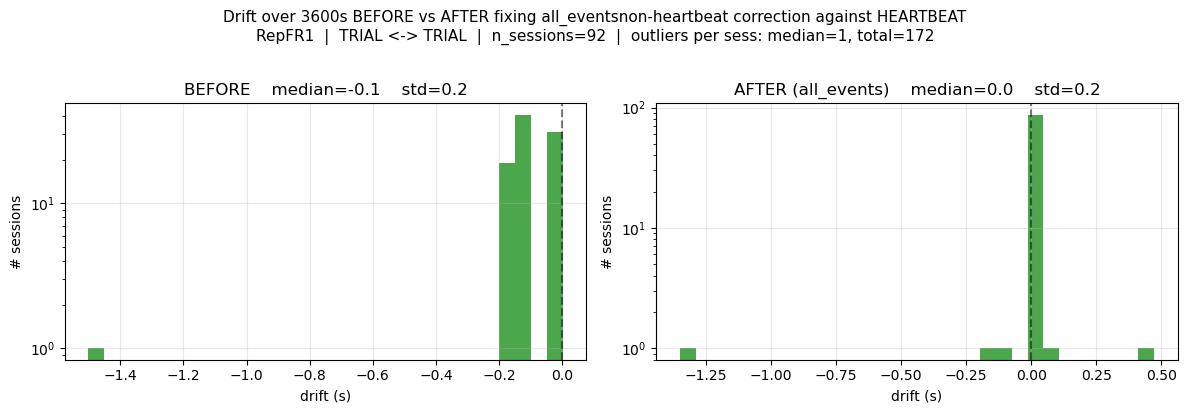

['/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_COUNTDOWN_COUNTDOWN_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_REST_REST_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_TRIALEND_TRIALEND_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_RECALL_RECALL_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_WORD_WORD_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_ISI_ISI_HEARTBEAT_all_events.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_all_events/RepFR1_TRIAL_TRIAL_HEAR

In [ ]:

cnh.plot_eegoffset_drift_distribution_gt(drift_df_gt, top_candidates)
cnh.plot_wallclock_drift_distribution_gt(drift_df_gt, top_candidates)


# Compared to GT — correcting outliers only

Repeat the GT comparison, but apply the non-heart fit only to events the fit flagged as outliers; inliers keep their raw timestamps. Tests whether a minimal, surgical correction is enough to recover GT-level alignment.

In [ ]:
# Per-candidate vs GT, outliers-only correction, rep session per experiment.
per_cand_out = cnh.compute_per_candidate_vs_gt(
    top_candidates, session_event_cache, gt_corrections,
    corrections_eval=corrections_eval, mode='outliers_only',
)
per_cand_out_rep = cnh.pick_rep_per_experiment(per_cand_out, corrections_eval)


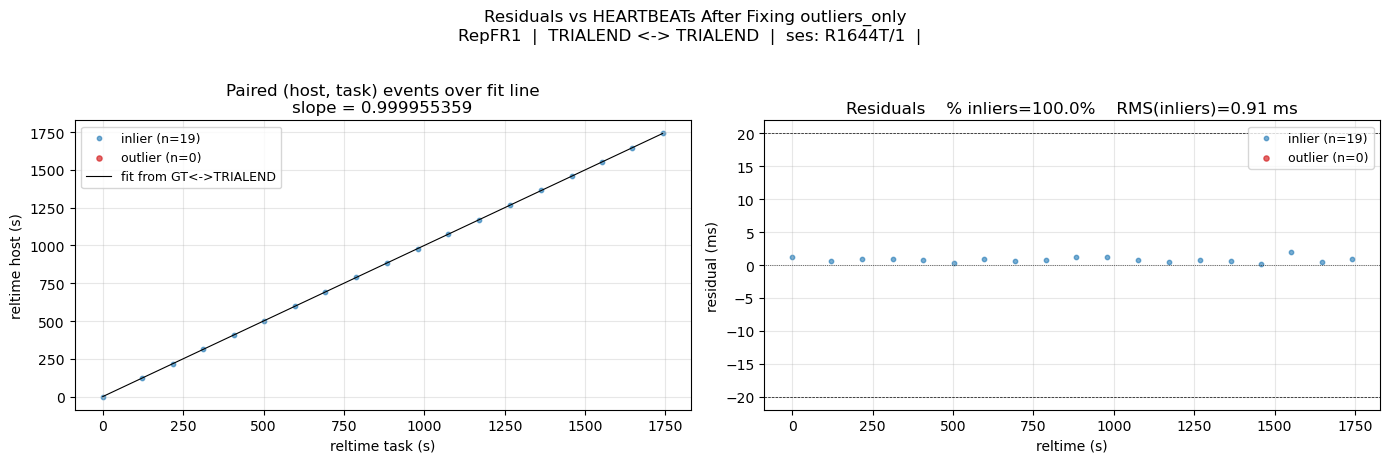

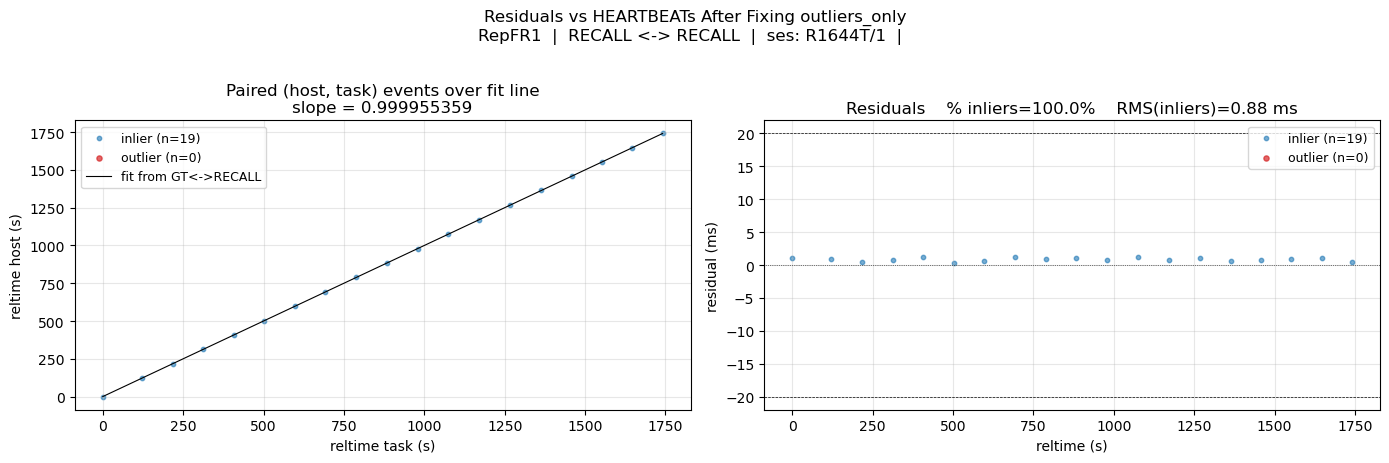

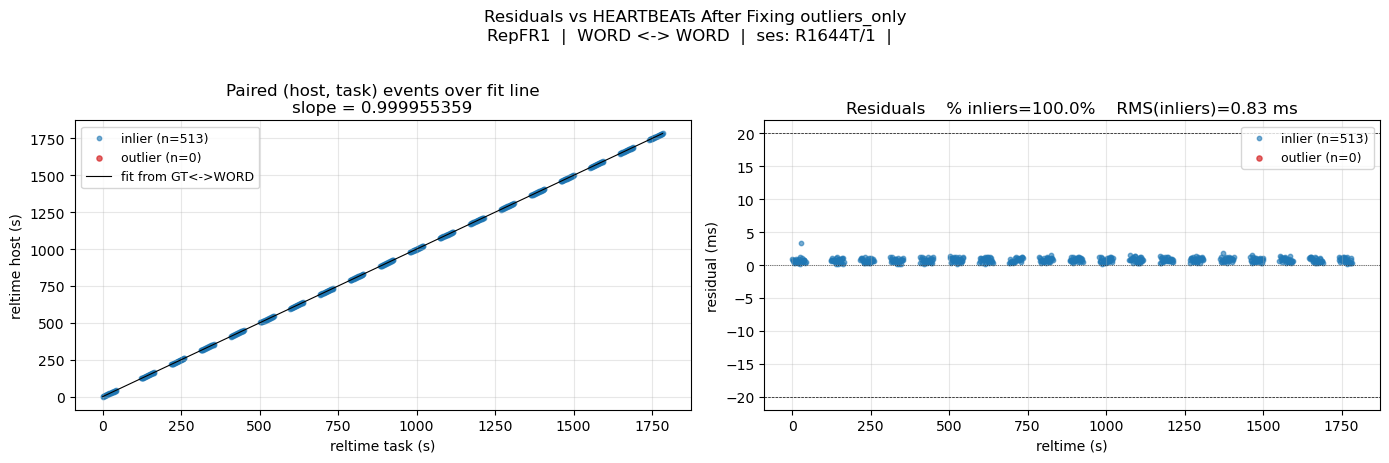

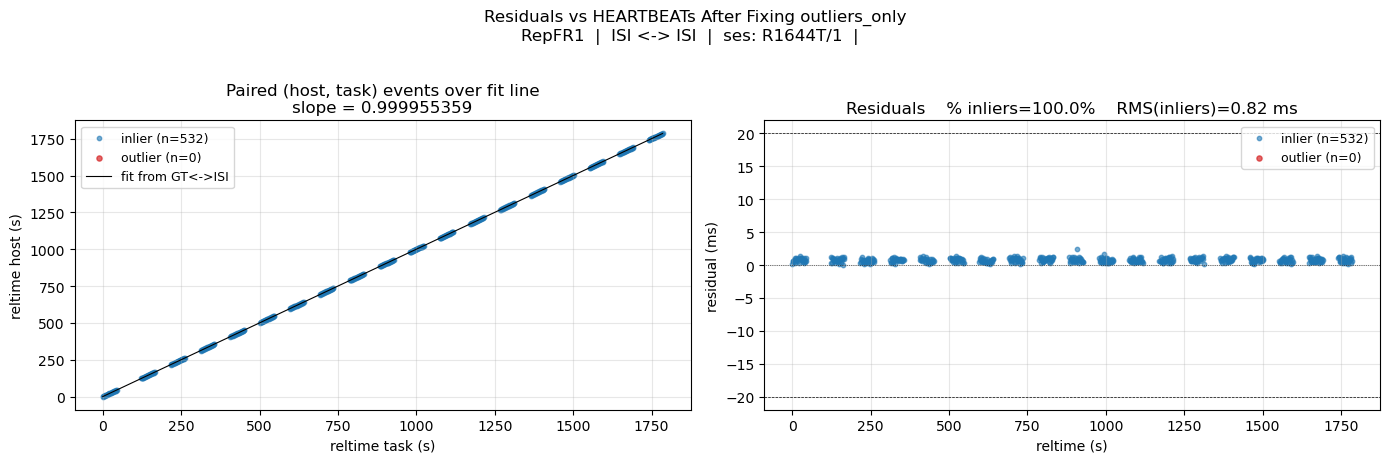

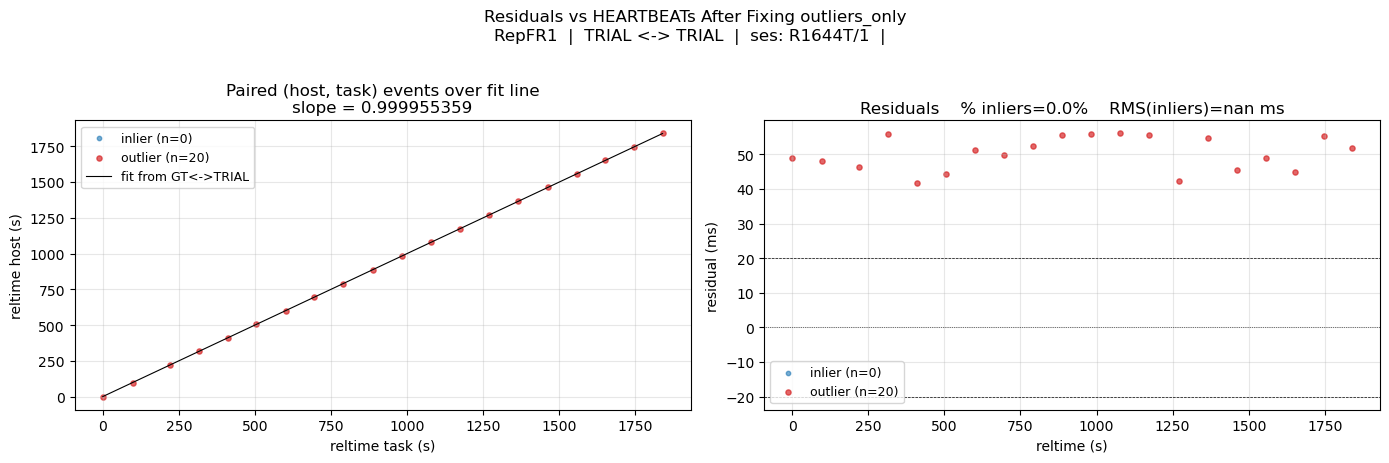

['/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR1_TRIALEND_TRIALEND_R1644T_ses1_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR1_RECALL_RECALL_R1644T_ses1_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR1_WORD_WORD_R1644T_ses1_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR1_ISI_ISI_R1644T_ses1_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR1_TRIAL_TRIAL_R1644T_ses1_outliers_only.png']

In [ ]:
cnh.plot_per_candidate_vs_gt(per_cand_out_rep)


## Drift — outliers-only correction, non-heart self-evaluation

For each session, snap outliers to the non-heart fit line `slope_nh*t + offset_nh`, keep inliers as raw `h`, then refit a slope `slope_eff` through the partially-corrected (t, corrected_h). **BEFORE** = drift implied by raw NH fit. **AFTER** = drift implied by `slope_eff` (the empirical drift remaining in the partially-corrected signal). Unlike all_events mode, AFTER is not trivially zero.

In [ ]:
# drift_df_nh_out = cnh.compute_drift_per_candidate(
#     corrections_eval, top_candidates,
#     session_event_cache=session_event_cache,
#     mode="outliers_only",
# )
# display(drift_df_nh_out.describe())
# cnh.plot_eegoffset_drift_distribution(drift_df_nh_out, top_candidates, mode="outliers_only")
# cnh.plot_wallclock_drift_distribution(drift_df_nh_out, top_candidates, mode="outliers_only")


## Drift — outliers-only correction, evaluated against heartbeat GT

**BEFORE** = actual drift in raw signal (from GT slope). **AFTER** = drift remaining after the outliers-only non-heart correction, evaluated against GT: `(slope_gt - slope_eff) * SESS_SECONDS * SFREQ_REF`. Tells us how much drift the outliers-only correction fails to remove, relative to the heartbeat ground truth.

In [ ]:
drift_df_gt_out = cnh.compute_drift_per_candidate_gt(
    corrections_eval, gt_corrections, top_candidates,
    session_event_cache=session_event_cache,
    mode="outliers_only",
)
# Attach the real per-session EEG samplerate and recompute drift in
# samples. Same pattern as the all_events drift cell above.
drift_df_gt_out['samplerate'] = drift_df_gt_out.apply(
    lambda r: samplerates_by_sess.get(
        (r['subject'], r['experiment'], int(r['session'])), float('nan')),
    axis=1,
)
drift_df_gt_out['drift_before_samples'] = (
    drift_df_gt_out['drift_before_ms'] * drift_df_gt_out['samplerate'] / 1000.0
)
drift_df_gt_out['drift_after_samples'] = (
    drift_df_gt_out['drift_after_ms'] * drift_df_gt_out['samplerate'] / 1000.0
)
display(drift_df_gt_out.describe())

,session,slope_nh,slope_gt,n_pairs,n_inliers,n_outliers,inlier_frac,drift_before_ms,drift_after_ms,slope_eff,samplerate,drift_before_samples,drift_after_samples
count,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,460.000000,460.000000,460.000000
mean,1.212903,0.999973,0.999970,235.572043,234.756989,0.815054,0.980561,-109.732079,-13.839520,0.999973,1010.869565,-110.355848,-14.242507
std,1.383339,0.000019,0.000044,269.476327,269.232016,2.710967,0.064231,159.686109,141.102723,0.000019,103.801933,161.062385,142.119875
min,0.000000,0.999866,0.999583,4.000000,3.000000,0.000000,0.380952,-1500.827622,-1350.519360,0.999866,1000.000000,-1500.827622,-1350.519360
25%,0.000000,0.999959,0.999959,21.000000,21.000000,0.000000,1.000000,-147.132266,-0.437464,0.999959,1000.000000,-147.164562,-0.451878
50%,1.000000,0.999965,0.999965,21.000000,21.000000,0.000000,1.000000,-125.373035,-0.124792,0.999965,1000.000000,-124.096497,-0.127324
75%,2.000000,0.999998,0.999998,567.000000,567.000000,0.000000,1.000000,-6.025412,0.101998,0.999998,1000.000000,-6.025412,0.102837
max,6.000000,1.000006,1.000000,588.000000,588.000000,28.000000,1.000000,0.964995,472.273107,1.000006,2000.000000,0.964995,472.273107


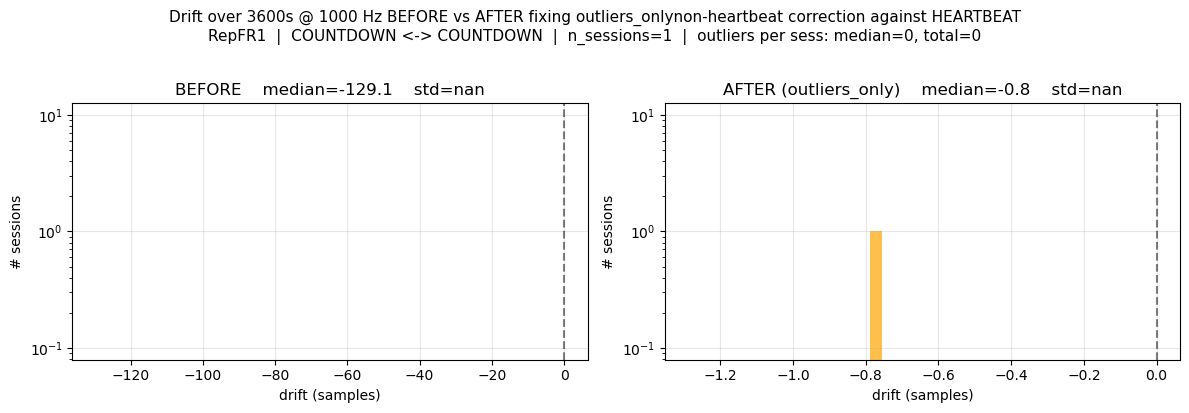

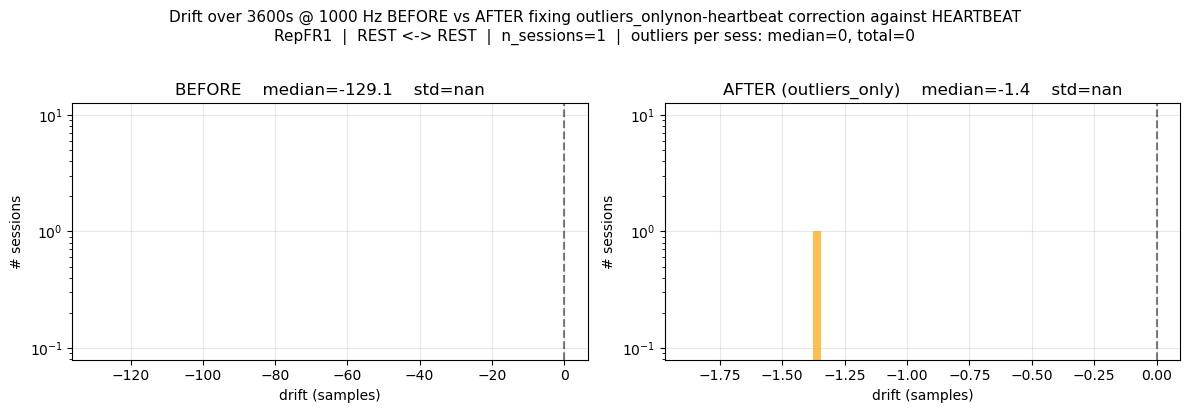

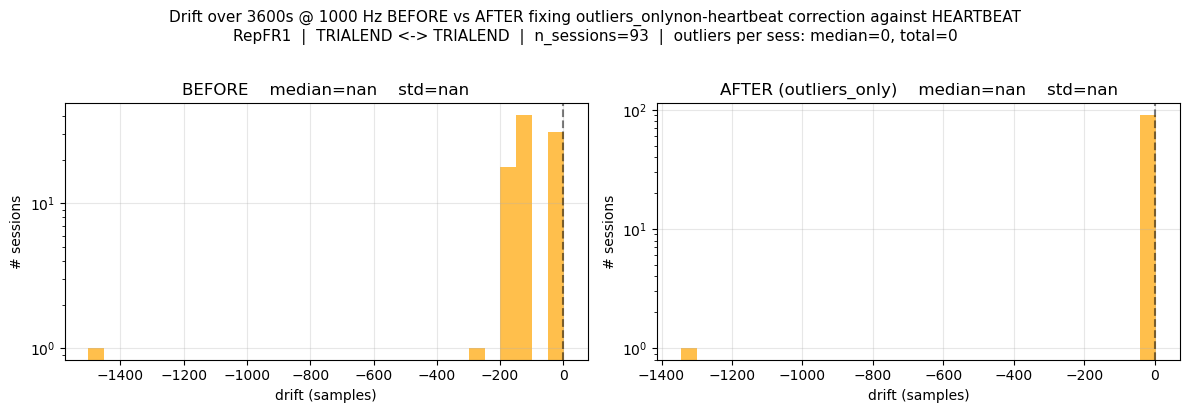

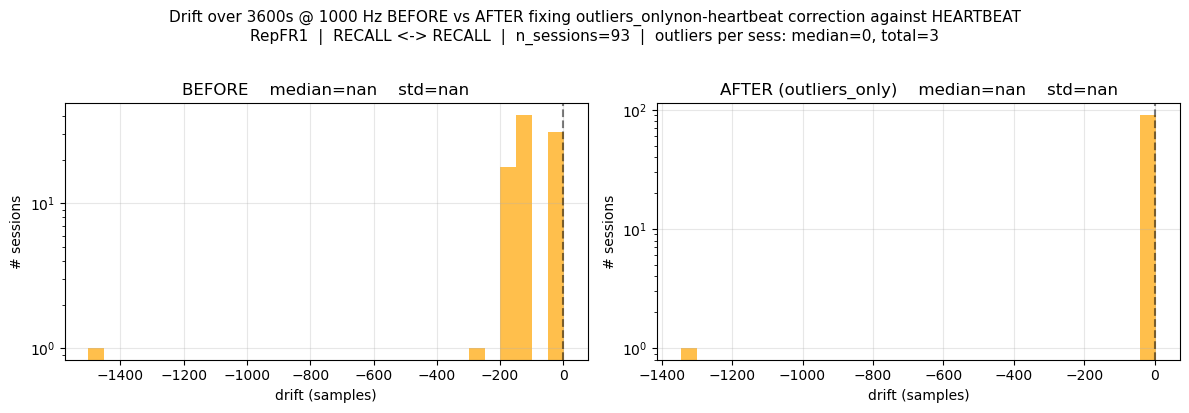

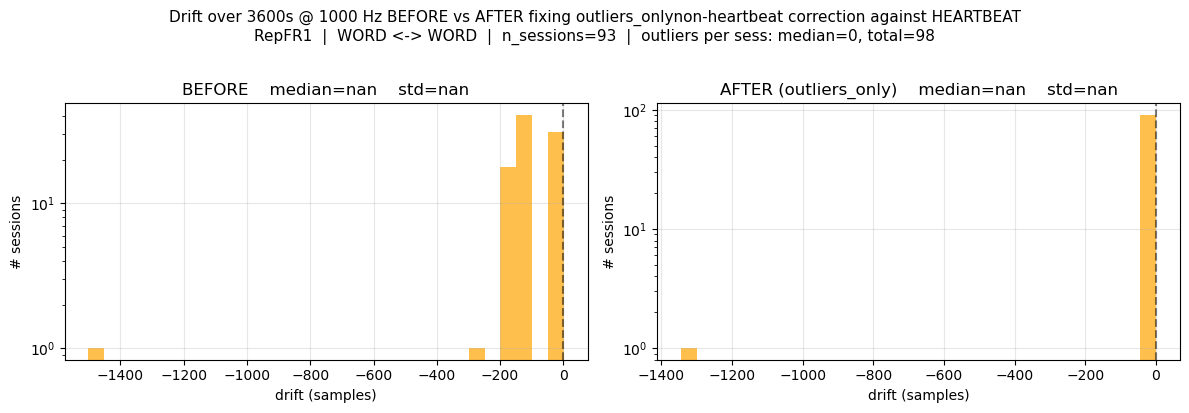

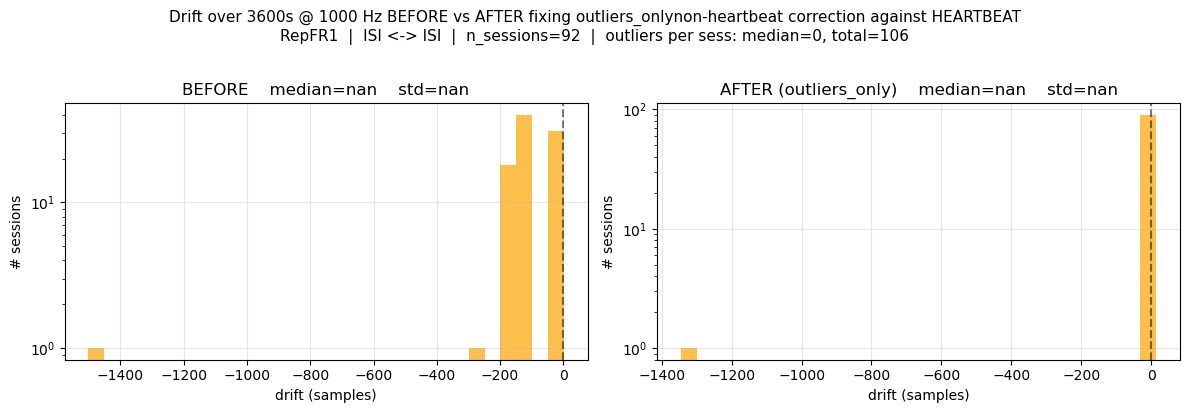

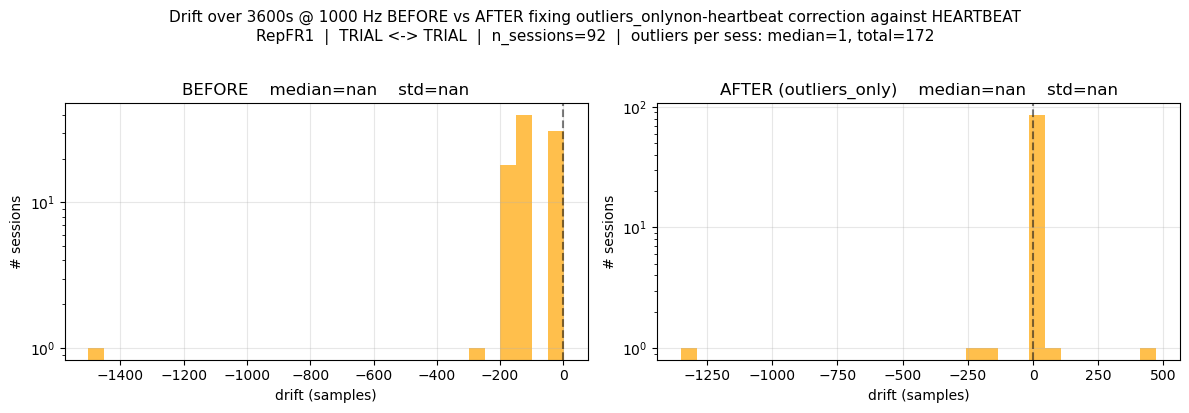

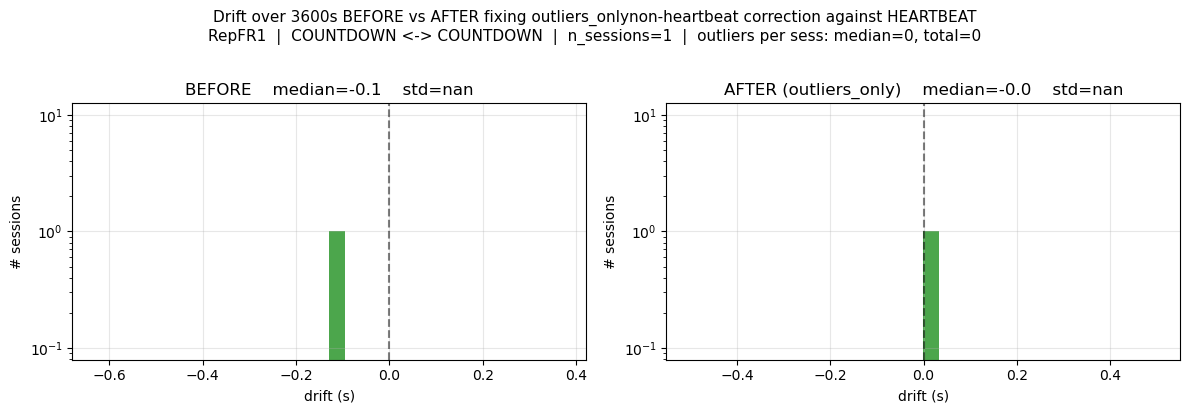

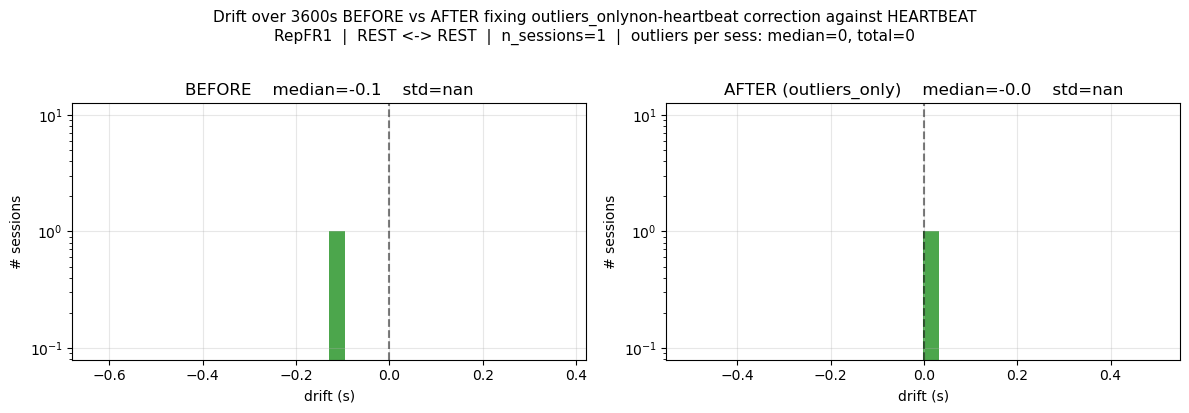

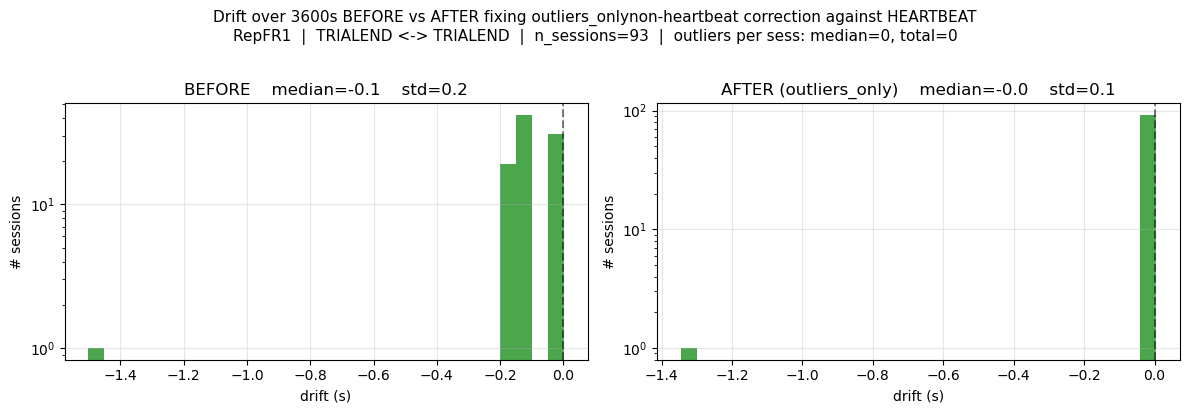

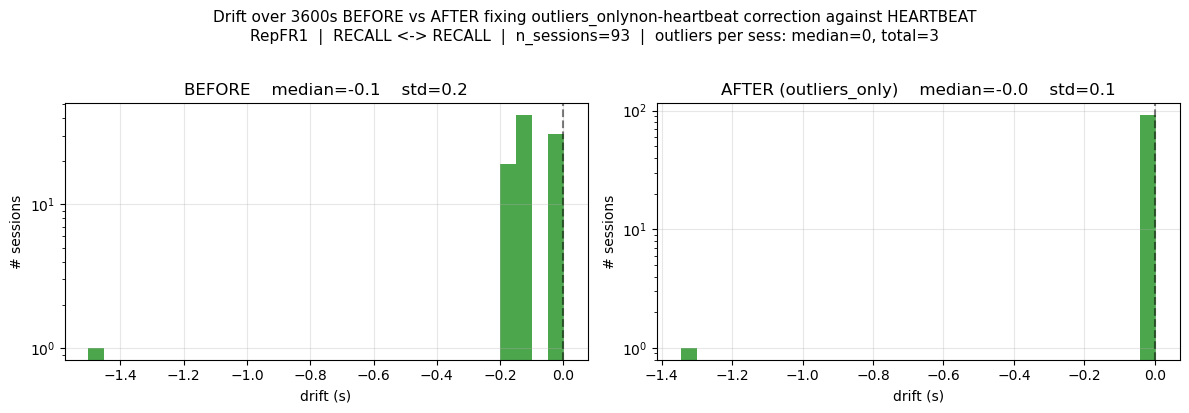

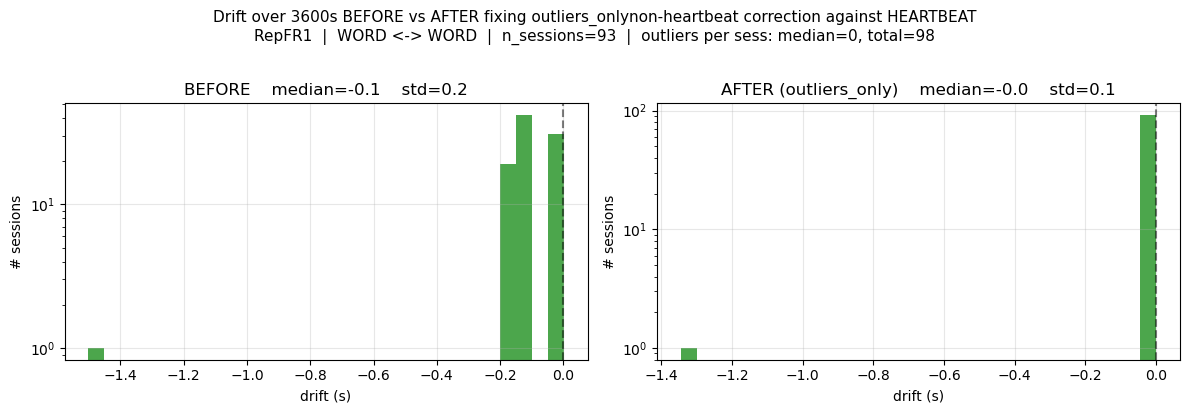

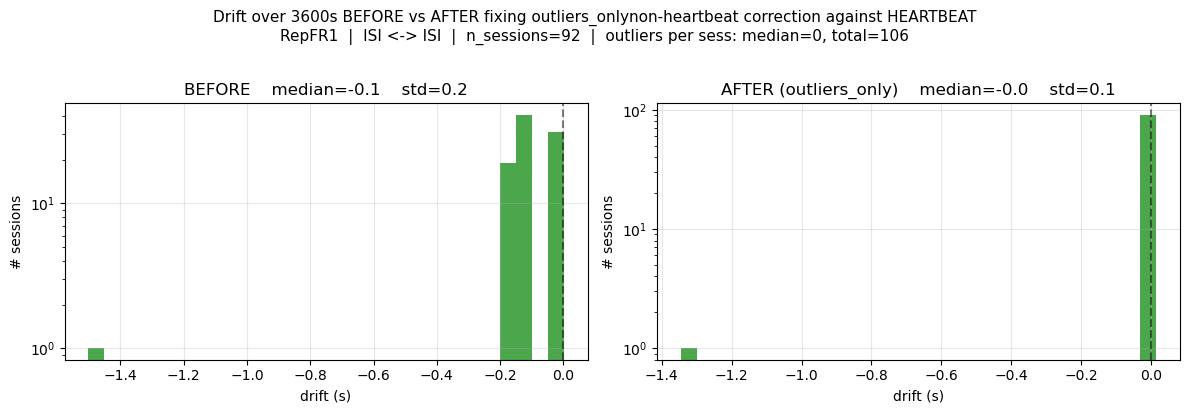

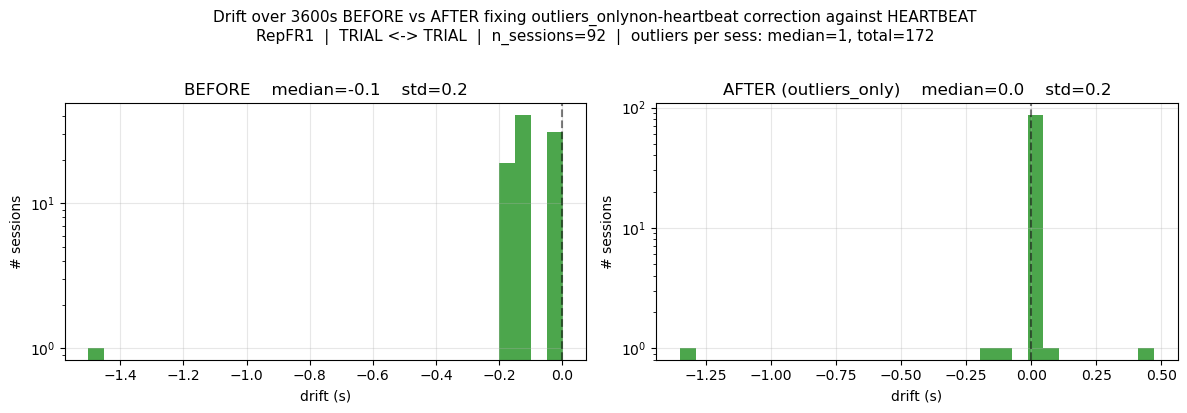

['/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_COUNTDOWN_COUNTDOWN_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_REST_REST_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_TRIALEND_TRIALEND_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_RECALL_RECALL_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_WORD_WORD_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEAT_outliers_only/RepFR1_ISI_ISI_HEARTBEAT_outliers_only.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_wallclock_HEARTBEA

In [ ]:

cnh.plot_eegoffset_drift_distribution_gt(drift_df_gt_out, top_candidates, mode="outliers_only")
cnh.plot_wallclock_drift_distribution_gt(drift_df_gt_out, top_candidates, mode="outliers_only")


# Compare modes — aggregated across sessions

Top-10 candidates per experiment compared mode-vs-mode. **Blue = `all_events`, orange = `outliers_only`.** Per-session RMS and residual mean/std are paired on `(subject, session)` between the two modes and compared with the paired Wilcoxon signed-rank test (significance stars: `*` p<.05, `**` p<.01, `***` p<.001, `ns` otherwise).

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,experiment,task_type,host_type,n_paired,all_events_mean,outliers_only_mean,statistic,pvalue
2,RepFR1,TRIALEND,TRIALEND,93,3.633332,3.633332,NaN,NaN
3,RepFR1,RECALL,RECALL,93,5.070489,3.707648,0.0,0.108809
4,RepFR1,WORD,WORD,93,6.704764,3.863744,0.0,0.003346
5,RepFR1,ISI,ISI,92,6.632130,3.897037,0.0,0.005062


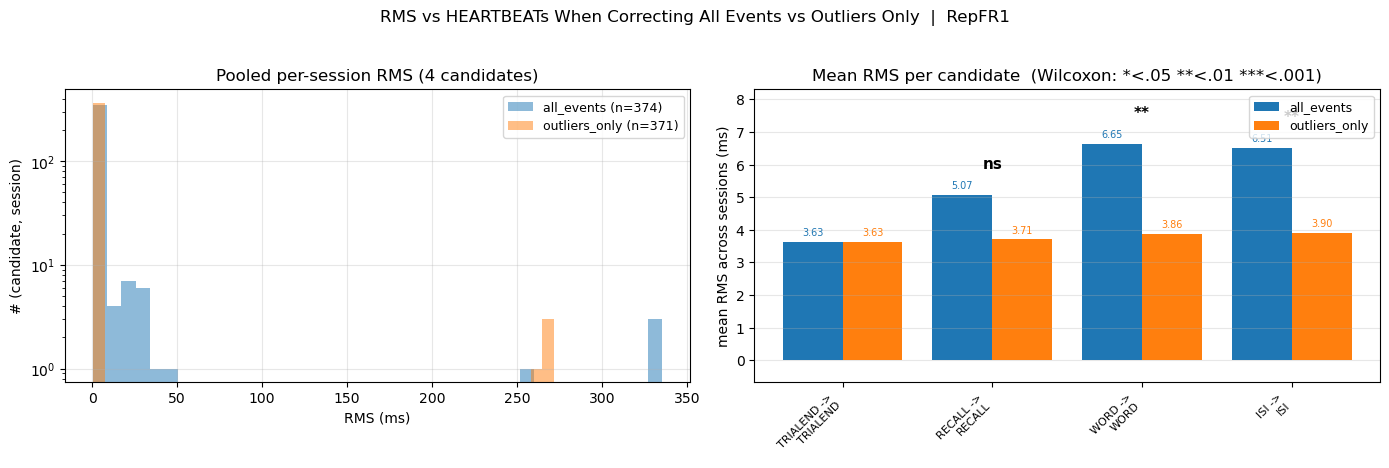

['/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR1_rms_comparison.png']

In [ ]:
# RMS comparison: pooled histogram + per-candidate mean RMS bars with
# paired Wilcoxon significance.
thresh = 50
long_df = cnh.aggregate_modes_per_session(per_cand_all, per_cand_out, top_candidates)
wilcoxon_rms = cnh.paired_wilcoxon_per_candidate(long_df, stat_col='rms').query("all_events_mean < @thresh and task_type not in ['COUNTDOWN', 'REST']")
display(wilcoxon_rms)
cnh.plot_rms_comparison(long_df, top_candidates, wilcoxon_rms)


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,experiment,task_type,host_type,n_paired,all_events_mean,outliers_only_mean,statistic,pvalue
2,RepFR1,TRIALEND,TRIALEND,93,-0.653975,-0.653975,NaN,NaN
3,RepFR1,RECALL,RECALL,93,0.232647,-0.719159,0.0,0.108809
4,RepFR1,WORD,WORD,93,0.230125,-0.805187,0.0,0.003346
5,RepFR1,ISI,ISI,92,0.220760,-0.811580,0.0,0.005062


,experiment,task_type,host_type,n_paired,all_events_mean,outliers_only_mean,statistic,pvalue
2,RepFR1,TRIALEND,TRIALEND,93,2.803006,2.803006,NaN,NaN
3,RepFR1,RECALL,RECALL,93,4.466745,2.749391,0.0,1.088094e-01
4,RepFR1,WORD,WORD,93,6.130043,2.864061,0.0,3.345618e-03
5,RepFR1,ISI,ISI,92,6.051207,2.879876,0.0,5.062032e-03
6,RepFR1,TRIAL,TRIAL,92,38.100007,6.553835,0.0,8.149782e-17


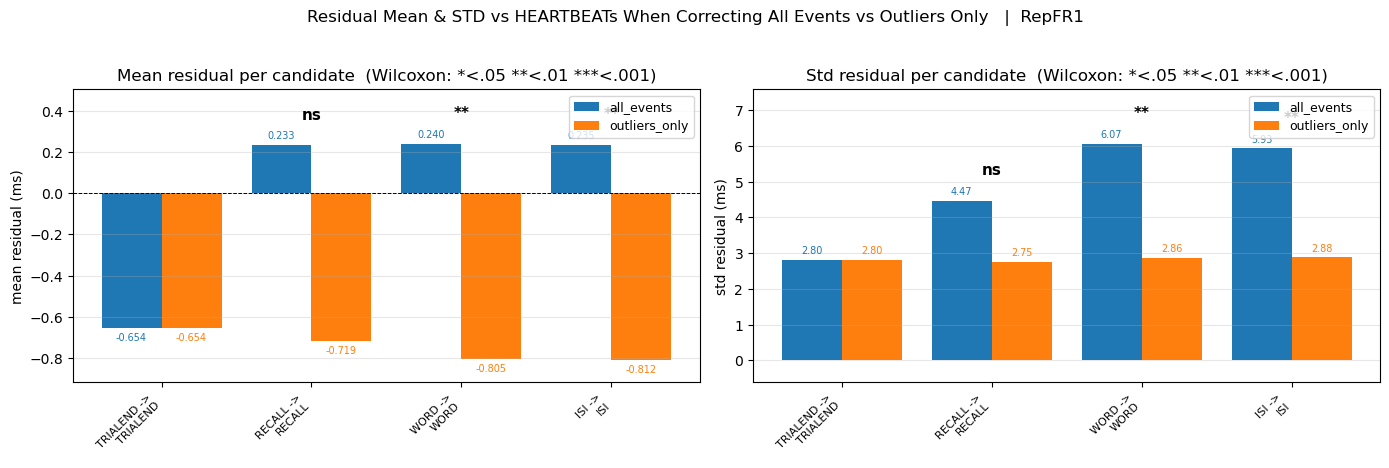

['/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR1_residual_mean_std.png']

In [ ]:
    # Residual mean & std comparison: two-panel bar chart per experiment,
# paired Wilcoxon on per-session mean / std residual.
wilcoxon_mean = cnh.paired_wilcoxon_per_candidate(long_df, stat_col='mean_resid').query("all_events_mean.abs() < @thresh and task_type not in ['COUNTDOWN', 'REST']")
wilcoxon_std  = cnh.paired_wilcoxon_per_candidate(long_df, stat_col='std_resid').query("all_events_mean.abs() < @thresh and task_type not in ['COUNTDOWN', 'REST']")
display(wilcoxon_mean)
display(wilcoxon_std)
cnh.plot_residual_mean_std_comparison(long_df, top_candidates,
                                      wilcoxon_mean, wilcoxon_std)
